# Friction Modeling



## Setup from Physically Feasible Dynamic Parameter Identification of the WAM Robot 7-DOF

### to run after setting up Amir's conda env 'id':
- python3 -m pip install sympy==0.7.5
- conda install matplotlib
- conda install scikit-learn

In [217]:
datafolder = 'data/'
tmpfolder = 'tmp/'
from sympy import init_printing
init_printing()

%matplotlib inline
import sympybotics

In [221]:
dataset = 'recdata/rbtlog_16.dat'

In [222]:
import pandas as pd
df = pd.read_csv(datafolder+dataset, sep=r'\s+')
print(df.shape)
print(len(df.columns))
df.head()

(15000, 9)
9


,1775684483.1609893,-1.0340856677953847,0.5057792583632142,-0.7504560049681084,0.7657120766195825,-1.643070647624989,-7.018326350122749,-1.2866084203897667,-1.8921808136988658
0,1.775684e+09,-1.034049,0.505779,-0.750456,0.765712,1.635716e-19,-9.062988,-0.741067,-2.088667
1,1.775684e+09,-1.034049,0.505725,-0.750456,0.765542,-1.961841e-02,-8.979293,-0.740882,-2.064454
2,1.775684e+09,-1.034013,0.505644,-0.750319,0.765456,9.786889e+00,0.170418,2.128813,0.800428
3,1.775684e+09,-1.033720,0.505834,-0.750000,0.765883,1.460809e+01,5.113618,4.449055,3.116415
4,1.775684e+09,-1.032953,0.506485,-0.749088,0.767161,1.597693e+01,7.777432,6.324709,4.987572


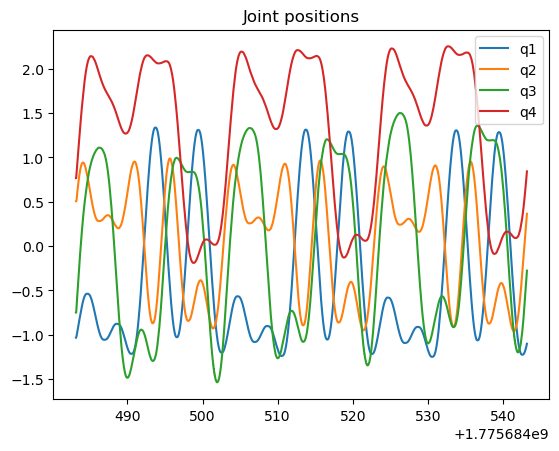

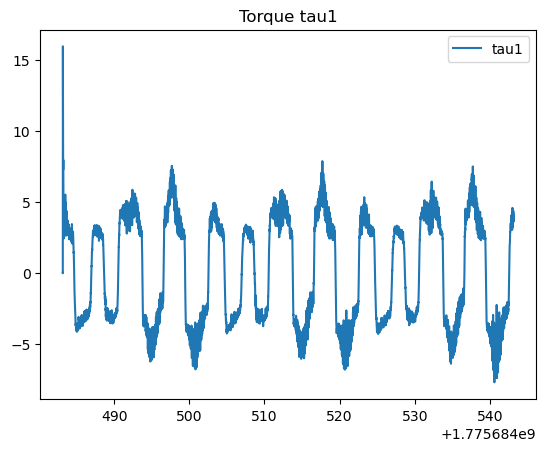

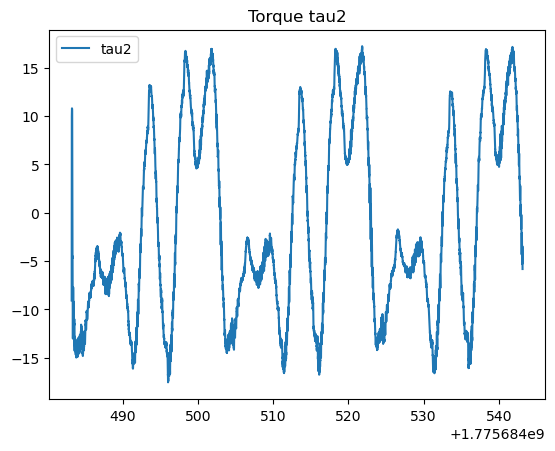

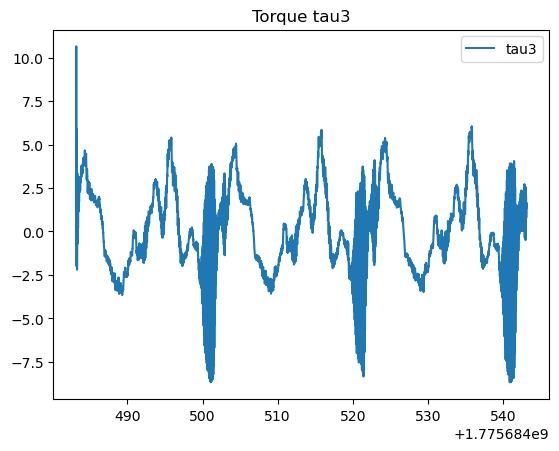

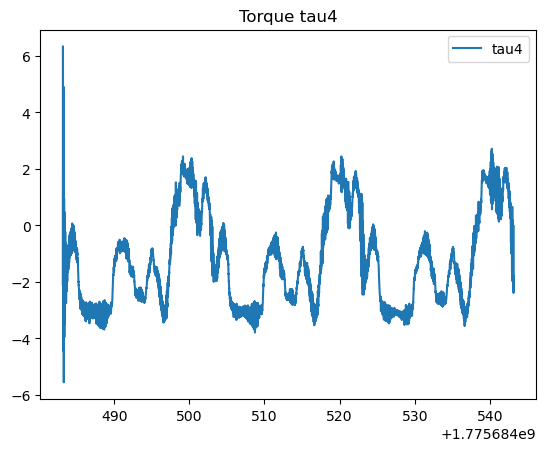

In [223]:
import matplotlib.pyplot as plt

plt.figure()
df.columns = [
    "t",
    "q1", "q2", "q3", "q4",
    "tau1", "tau2", "tau3", "tau4"
]
for col in ["q1", "q2", "q3", "q4"]:
    plt.plot(df["t"], df[col], label=col)
plt.legend()
plt.title("Joint positions")
plt.show()

plt.figure()
for col in ["tau1", "tau2", "tau3", "tau4"]:
    plt.plot(df["t"], df[col], label=col)
    plt.legend()
    plt.title(f"Torque {col}")

    plt.show()


In [224]:
# rbtdef = sympybotics.RobotDef("WAM Arm 7 DOF",
#             [("-pi/2", 0, 0, "q"),
#              ("pi/2", 0, 0, "q"),
#              ("-pi/2", 0.045, 0.55, "q"),
#              ("pi/2", -0.045, 0, "q"),
#              ("-pi/2", 0, 0.3, "q"),
#              ("pi/2", 0, 0, "q"),
#              (0, 0, 0.06, "q")],
#             dh_convention="standard")

# rbtdef = sympybotics.RobotDef("WAM 2-DOF",
#     [("-pi/2", 0, 0, "q"),
#      (0, 0.045, 0.55, "q")],
#     dh_convention="standard"
# )

rbtdef = sympybotics.RobotDef("WAM Arm 4 DOF",
            [("-pi/2", 0, 0, "q"),
             ("pi/2", 0, 0, "q"),
             ("-pi/2", 0.045, 0.55, "q"),
             ("pi/2", -0.045, 0, "q")],
            dh_convention="standard")

# rbtdef = sympybotics.RobotDef("WAM Arm 4 DOF",
#             [(0, 0, 0, "q"),|
#              ("-pi/2", 0, 0, "q"),
#              ("pi/2", 0, 0, "q"),
#              ("-pi/2", 0.045, 0.55, "q")],
#             dh_convention="standard")
rbtdef.frictionmodel = None

In [225]:
import math
import numpy
from math import pi

# Register them in global scope for exec() to see
import builtins
builtins.math = math
builtins.numpy = numpy
builtins.pi = pi

from sympy import iterables


In [226]:
%time rbt = sympybotics.RobotDynCode(rbtdef)
%time rbt.calc_base_parms()

CPU times: user 1.37 s, sys: 0 ns, total: 1.37 s
Wall time: 1.37 s
CPU times: user 903 ms, sys: 26.9 ms, total: 930 ms
Wall time: 796 ms


In [227]:
import pickle
with open(tmpfolder + 'robotmodels/wam4_model.pkl', 'wb') as file:
    pickle.dump( rbt, file )

with open(tmpfolder +  'robotmodels/wam4_model.pkl', 'rb' ) as file:
          rbt = pickle.load( file )

rbt.dyn.n_dynparms, rbt.dyn.n_base

rbt.dyn.dynparms.n()
rbt.dyn.baseparms.n()

Matrix([
[                                                 L_1yy + L_2zz],
[L_2xx - L_2zz + L_3zz - 1.1*l_3y + 0.300475*m_3 + 0.300475*m_4],
[                                                         L_2xy],
[                                                         L_2xz],
[        L_2yy + L_3zz - 1.1*l_3y + 0.300475*m_3 + 0.300475*m_4],
[                                                         L_2yz],
[                                                          l_2x],
[                             l_2z - l_3y + 0.55*m_3 + 0.55*m_4],
[                          L_3xx - L_3zz + L_4zz + 0.002025*m_3],
[                                            L_3xy - 0.045*l_3y],
[                                                         L_3xz],
[                    L_3yy + L_4zz - 0.002025*m_3 - 0.00405*m_4],
[                                                         L_3yz],
[                                  l_3x + 0.045*m_3 + 0.045*m_4],
[                                                   l_3z + l_4y],
[

In [228]:
import numpy as np

# Step 1: Convert symbolic matrix to NumPy array
Pb_matrix = np.array(rbt.dyn.Pb.tolist(), dtype=np.float64)  # already 0/1
Pb_flat = Pb_matrix.flatten()

# Step 2: Generate C++ code
cpp_array_str = 'double Pb[1440] = {\n'
for i, val in enumerate(Pb_flat):
    cpp_array_str += f'{int(val)}, '  # write as integer 0 or 1
    if (i + 1) % 12 == 0:  # break line every 12 entries
        cpp_array_str += '\n'
cpp_array_str += '};'

with open('Pb_array.cpp', 'w') as f:
    f.write(cpp_array_str)

## Load Data

In [229]:
import pandas as pd
df = pd.read_csv(datafolder +  dataset, sep='\t')
print(df.head())

  1775684483.1609893 -1.0340856677953847 0.5057792583632142 -0.7504560049681084 0.7657120766195825 -1.643070647624989 -7.018326350122749 -1.2866084203897667 -1.8921808136988658
0  1775684483.16385 -1.034049144443292 0.50577925...                                                                                                                            
1  1775684483.1678512 -1.034049144443292 0.505724...                                                                                                                            
2  1775684483.1718352 -1.0340126210911995 0.50564...                                                                                                                            
3  1775684483.1758401 -1.0337204342744595 0.50583...                                                                                                                            
4  1775684483.17995 -1.0329534438805166 0.5064851...                                                               

(15000, 4)
(15001, 9)
(15000, 4)


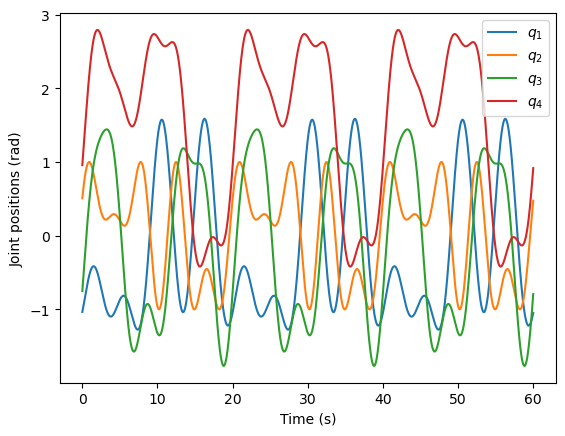

In [230]:
import pickle
import sympybotics
import numpy

with open(tmpfolder +  'robotmodels/wam4_model.pkl', 'rb' ) as file:
          rbt = pickle.load( file )

with open(datafolder + 'trajectories/traj_shwfl_abq0.pkl', 'rb') as file:
    s_h_wf_l, a_b_q0 = pickle.load(file, encoding='latin1')

h = 0.004
decimate = 1
h_plot = h*decimate # downsample it so that it has the frequency of 500 (originally it has been 1000)

with open(datafolder +  'trajectories/traj_4.dat', 'r' ) as file:
          q_ref_orig = numpy.loadtxt(file)
print(q_ref_orig.shape)
q_ref = q_ref_orig
with open(datafolder + dataset, 'r' ) as file:
          q_raw_orig = numpy.loadtxt(file)
print(q_raw_orig.shape)
s = q_ref_orig.shape[0] // decimate

q_ref = numpy.zeros((s, rbt.dof))
for i in range(s):
    q_ref[i, :] = q_ref_orig[i*decimate, :]
print(q_ref.shape)

si = 0
sf = si + 60/h_plot
t = numpy.arange(sf-si) * h_plot



from matplotlib import pyplot as plt
plt.close()

si = int(si)
sf = int(sf)

for i in range(rbt.dof):
    plt.plot(t,q_ref[si:sf,i], label="$q_%d$"%(i+1))
plt.legend()

plt.xlabel("Time (s)")
plt.ylabel("Joint positions (rad)")

plt.show()

## Regression Setup



In [231]:
import os
import pickle
import math
import sympy
import numpy
import sympybotics

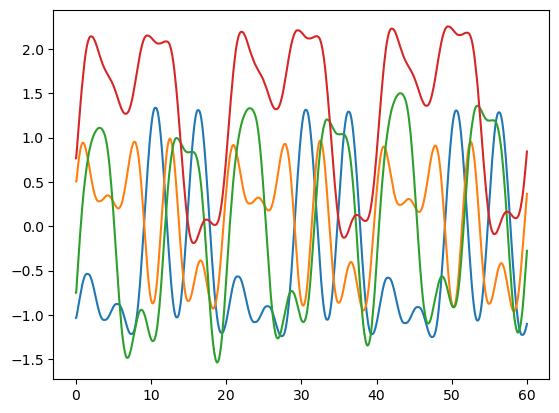

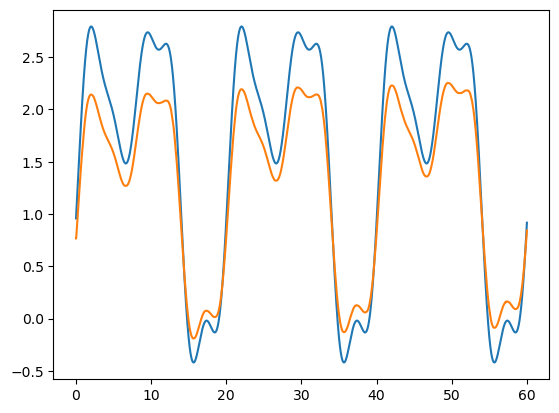

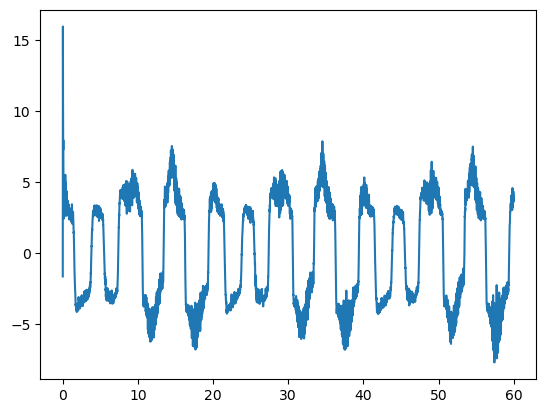

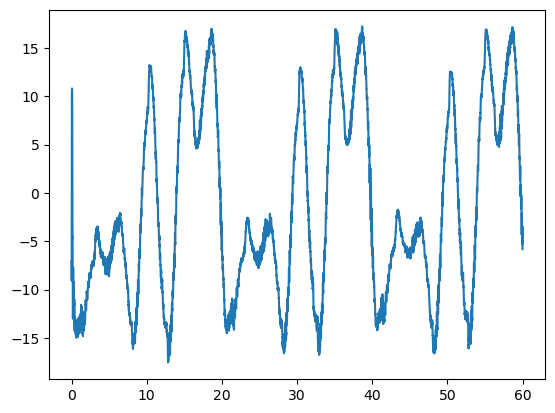

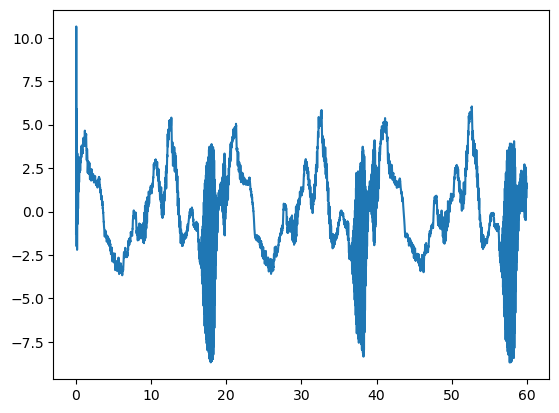

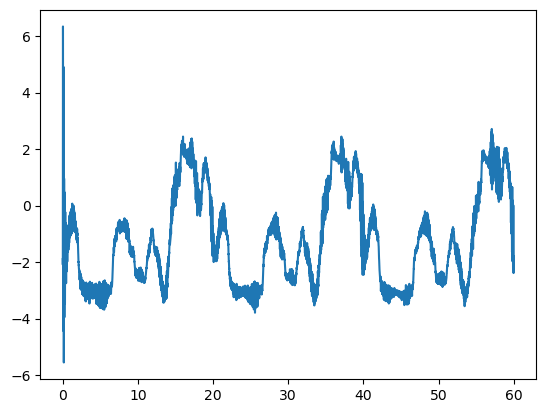

In [232]:
with open(tmpfolder +  'robotmodels/wam4_model.pkl', 'rb' ) as file:
          rbt = pickle.load( file )

from support_funcs.regr_data_proc import read_data
t_raw, q_raw, tau_raw, t_ref, q_ref = read_data( rbt.dof, 0.004,
                                                datafolder + dataset,
                                                datafolder + 'trajectories/traj_4.dat')
t_raw = t_raw - t_raw[0]

from matplotlib import pyplot as plt
plt.close()

for i in range(q_raw.shape[1]):
    plt.plot(t_raw,q_raw[:,i])

plt.show()

from matplotlib import pyplot as plt
plt.close()

joint = 4
plt.plot(t_ref,q_ref[:,joint-1])
plt.plot(t_raw,q_raw[:,joint-1])

plt.show()

plt.close()

for i in range(tau_raw.shape[1]):
    plt.plot(t_raw,tau_raw[:,i])
    plt.show()

plt.show()

# del t_raw, q_raw, tau_raw, t_ref, q_ref

In [233]:
print(t_raw[0])
print(t_raw[1])
print(t_raw[2])

0.0
0.0028607845306396484
0.00686192512512207


In [234]:
# with open(datafolder +  'trajectories/traj_shwfl_abq0.pkl', 'rb' ) as file:
#           s_h_wf_l, a_b_q0 = pickle.load(file)
with open(datafolder + 'trajectories/traj_shwfl_abq0.pkl', 'rb') as file:
    s_h_wf_l, a_b_q0 = pickle.load(file, encoding='latin1')

print(dict(zip(('S', 'h', 'wf', 'L'), s_h_wf_l)))
print('\n')

fc_mult = 10

wf = float(s_h_wf_l[2])
L = float(s_h_wf_l[3])
fc = fc_mult * ( wf / (2*math.pi) * L )
fc

fc_q = fc
fc_dq = fc
fc_ddq = fc

fc_tau = fc

si = int(3/0.001)
sf = -int(1/0.001)-172

{'S': 500.0, 'h': 0.04, 'wf': 0.3141592653589793, 'L': 5.0}




In [235]:
rec_h = 0.004 # sampling time
from support_funcs.regr_data_proc import read_data, diff_and_filt_data, gen_regr_matrices
from support_funcs.utils import _fprint

t_raw, q_raw, tau_raw, t_ref, q_ref = read_data(dof=rbt.dof, h=rec_h,
                                                rbtlogfile=datafolder + dataset,
                                                trajreffile=datafolder + 'trajectories/traj_4.dat')

print("tau_raw full joint4:", tau_raw[:, 3].min(), tau_raw[:, 3].max())

q, dq, ddq, tau = diff_and_filt_data(dof=rbt.dof, h=rec_h,  q_raw=q_raw, tau_raw=tau_raw,
                               fc_q=fc_q, fc_dq=fc_dq, fc_ddq=fc_ddq, fc_tau=fc_tau)

print("tau filtered full joint4:", tau[:, 3].min(), tau[:, 3].max())

t_raw = t_raw[si:sf]; q_raw = q_raw[si:sf]; tau_raw = tau_raw[si:sf]
q = q[si:sf]; dq = dq[si:sf]; ddq = ddq[si:sf]; tau = tau[si:sf]


print("tau_raw sliced joint4:", tau_raw[si:sf, 3].min(), tau_raw[si:sf, 3].max())
print("tau filtered sliced joint4:", tau[si:sf, 3].min(), tau[si:sf, 3].max())

t_raw = t_raw - t_raw[0]

t = numpy.array(range(q.shape[0])) * rec_h
print(np.shape(q))
H_S, W, omega, Q1, R1, rho1 = gen_regr_matrices(rbt, q, dq, ddq, tau)

# W is the regression matrix to appropriately find tau_rbd


_fprint(' (cond=%f)'%numpy.linalg.cond(W))

_fprint('save')

%time \
numpy.savez_compressed(tmpfolder + 'procdata/raw', t=t_raw, q=q_raw, tau=tau_raw);\
numpy.savez_compressed(tmpfolder + 'procdata/proc', t=t, q=q, dq=dq, ddq=ddq, tau=tau); \
numpy.savez_compressed(tmpfolder + 'procdata/regr', W=W, omega=omega, Q1=Q1, R1=R1, rho1=rho1)

# del t_raw, q_raw, tau_raw, t, q, dq, ddq, tau, W, omega, Q1, R1, rho1


tau_raw full joint4: -5.550959510693717 6.3373442742733985
tau filtered full joint4: -3.2948387500954346 2.1374862769383514
tau_raw sliced joint4: -3.790074372662456 2.441662560076463
tau filtered sliced joint4: -3.2948387500954346 1.9627279416335874
(10829, 4)
 (cond=37.692691)
save
CPU times: user 465 ms, sys: 3.4 ms, total: 469 ms
Wall time: 469 ms


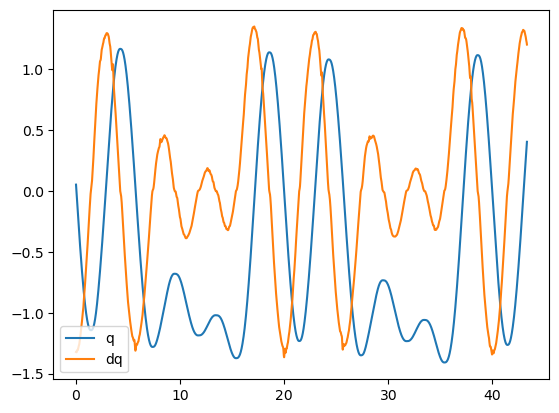

In [182]:
plt.plot(t,q[:,0], label='q')
plt.plot(t,dq[:,0],label='dq')
# plt.plot(t,ddq[:,0],label='ddq')
plt.legend()
plt.show()

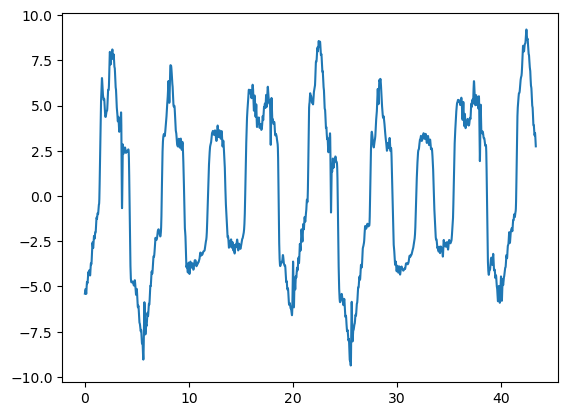

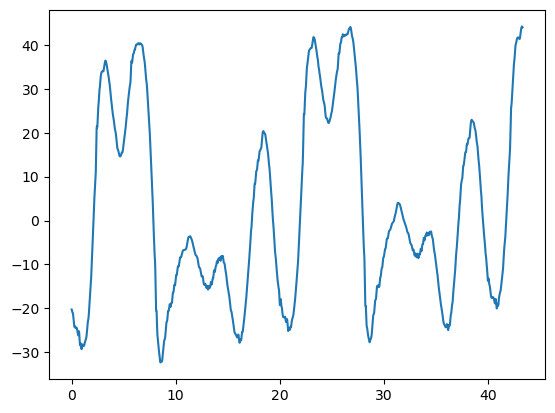

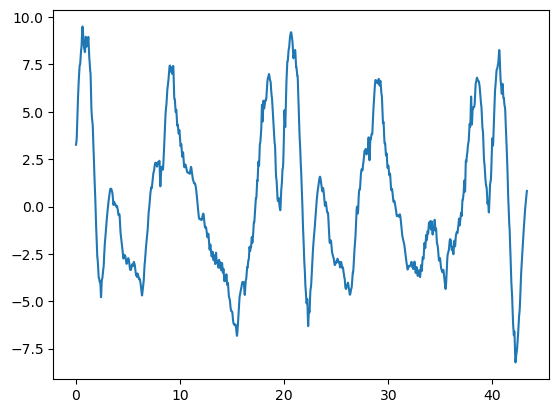

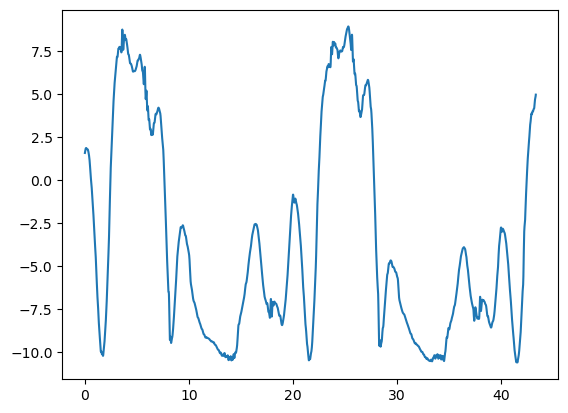

In [188]:
for i in range(tau.shape[1]):
    plt.plot(t_raw,tau[:,i])
    plt.show()

In [189]:
print("W.shape",W.shape)
print("tau.shape:",tau.shape)
tau_vec = tau.reshape(-1,1)
print(tau_vec.shape)   # (43316,)

W.shape (43316, 22)
tau.shape: (10829, 4)
(43316, 1)


In [190]:
# rbt.dyn.baseparms
print(W.shape)
print(tau.shape)

beta, *_ = np.linalg.lstsq(W, tau_vec, rcond=None)
tau_rbd = W @ beta #friction from the reduced H_S == W regressor model

(43316, 22)
(10829, 4)


In [191]:
print("tau_rbd.shape", tau_rbd.shape)
print("tau_vec.shape", tau_vec.shape)

tau_rbd = tau_rbd.reshape(-1,1)
tau_vec= tau_vec.reshape(-1,1)

print("tau_rbd.shape", tau_rbd.shape)
print("tau_vec.shape", tau_vec.shape)

tau_residual = tau_vec - tau_rbd

rmse = np.sqrt(np.mean(np.square((tau_residual))))

rmse 
# rbd model:
    #include no friction modeling ==> rmse = 2.66
    #include only viscous ==> rmse = 1.16
    #include both colomnb and viscous ==> rmse = 0.814

tau_rbd.shape (43316, 1)
tau_vec.shape (43316, 1)
tau_rbd.shape (43316, 1)
tau_vec.shape (43316, 1)


2.6592263411943384

In [192]:
tau_vec.shape

(43316, 1)

In [193]:
# print(tau_vec[:,0])

tau_rbd.shape (43316, 1)
tau_vec.shape (43316, 1)
[-5.40002203 -5.38910338 -5.37602372 ...  2.78369996  2.76000552
  2.74353505]
joint 0 RMSE: 4.218293290224343


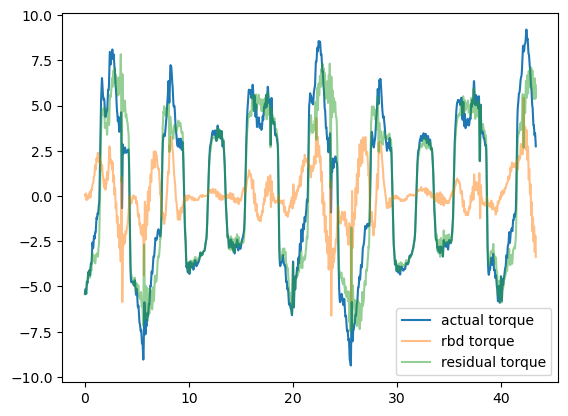

[-20.25849267 -20.29618109 -20.33780864 ...  44.03808531  44.01464802
  43.99074269]
joint 1 RMSE: 2.4133050281826574


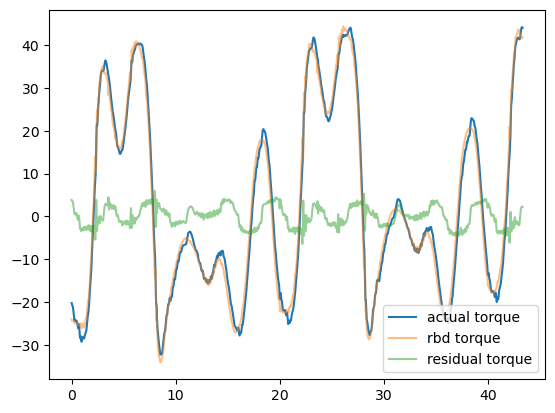

[3.26378397 3.2917412  3.31481851 ... 0.80480229 0.81429388 0.8236675 ]
joint 2 RMSE: 1.9549514753604933


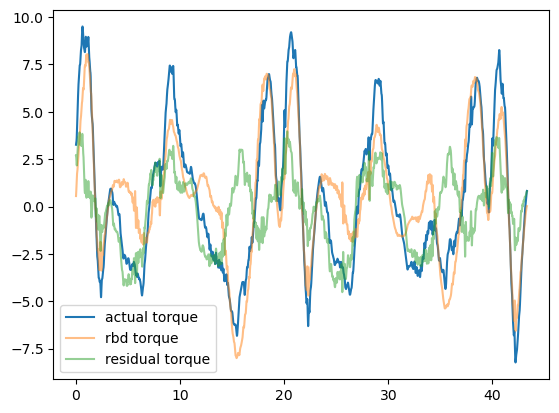

[1.58568087 1.59660202 1.60875749 ... 4.93075699 4.95658056 4.98237329]
joint 3 RMSE: 0.9198174940659323


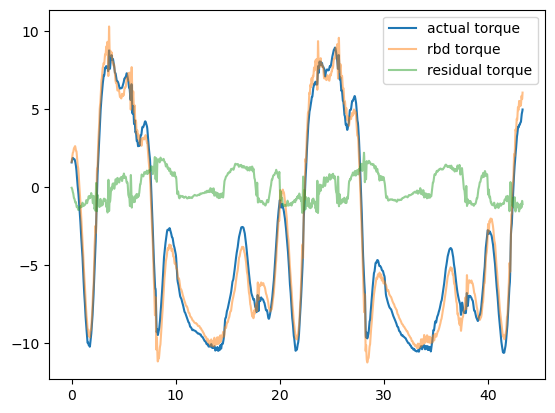

In [194]:
######################################
# Visualize the torques in each joint #
######################################

from matplotlib import pyplot as plt
plt.close()

print("tau_rbd.shape", tau_rbd.shape)
print("tau_vec.shape", tau_vec.shape)
tau_vec = tau_vec.reshape(-1,rbt.dof)
tau_rbd = tau_rbd.reshape(-1,rbt.dof)
tau_residual = tau_residual.reshape(-1,rbt.dof)

# one plot for each of the degrees of freedom

for i in range(rbt.dof):
    print(tau_vec[:,i])
    plt.plot(t, tau_vec[:,i], alpha = 1.0, label='actual torque') # actual torque
    
    plt.plot(t, tau_rbd[:,i],  alpha = 0.5,  label='rbd torque') # modeled by rbd
    plt.plot(t, tau_residual[:,i],  alpha = 0.5,  label='residual torque') # actual torque
    rmse = np.sqrt(np.mean(np.square((tau_residual[:,i]))))
    print(f"joint {i} RMSE: {rmse}")
    plt.legend()
    plt.show()


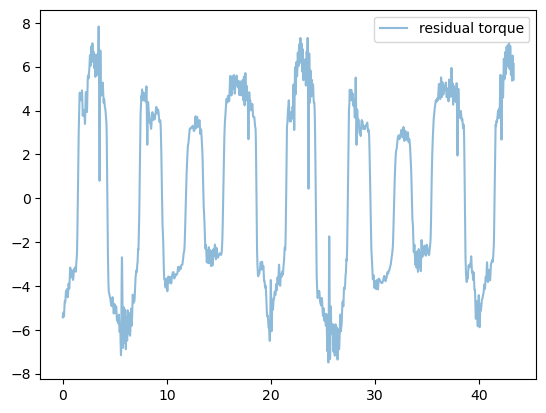

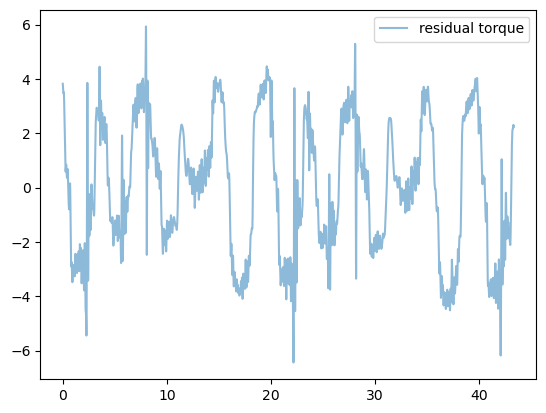

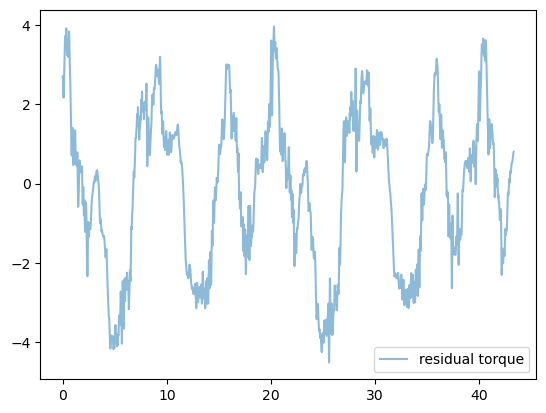

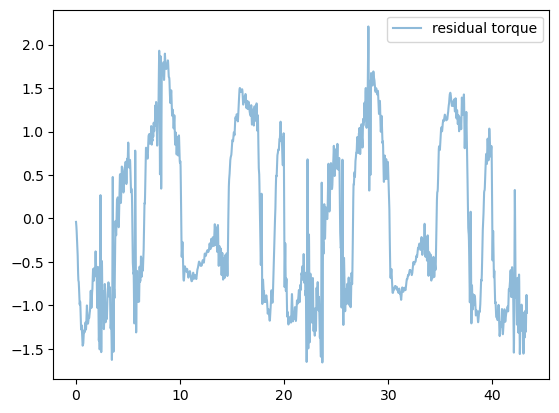

In [195]:
# Visualize only the residual in each joint

# TODO: Do i need to normalize this error when I visualize it?


from matplotlib import pyplot as plt
plt.close()

tau_residual = tau_residual.reshape(-1,rbt.dof)

# one plot for each of the degrees of freedom

for i in range(rbt.dof):
    plt.plot(t, tau_residual[:,i],  alpha = 0.5,  label='residual torque') # actual torque
    plt.legend()
    plt.show()


# Friction Modeling

Here are some useful functions below...

In [196]:
import numpy as np
import sympy as sp
from sklearn.preprocessing import PolynomialFeatures

def generate_regressor(
    q,
    dq,
    ddq,
    basis_type=None,
    poly_deg=2,
    poly_in=None,
    trig_in=None,
    include_bias=False,
    custom_basis_function=None,
    symbols=None
):
    if basis_type is None:
        basis_type = []
    if custom_basis_function is None:
        custom_basis_function = []

    q = np.asarray(q)
    dq = np.asarray(dq)
    ddq = np.asarray(ddq)

    if q.ndim == 1:
        q = q[:, None]
    if dq.ndim == 1:
        dq = dq[:, None]
    if ddq.ndim == 1:
        ddq = ddq[:, None]

    N = q.shape[0]

    if poly_in is None:
        poly_in = (q, dq, ddq)
    if trig_in is None:
        trig_in = (q, dq, ddq)

    basis_populated = []

    for b in basis_type:
        if b == 'Coulomb':
            basis_populated.append(np.sign(dq))
        elif b == 'viscous':
            basis_populated.append(dq)
        elif b == 'poly':
            X_poly = np.concatenate(poly_in, axis=1)
            poly = PolynomialFeatures(degree=poly_deg, include_bias=False)
            basis_populated.append(poly.fit_transform(X_poly))
        elif b == 'trig':
            X_trig = np.concatenate(trig_in, axis=1)
            basis_populated.append(np.concatenate([np.sin(X_trig), np.cos(X_trig)], axis=1))
        else:
            raise ValueError(f"Unknown basis type: {b}")

    if custom_basis_function:
        if symbols is None:
            raise ValueError("symbols must be provided for custom basis")
    
        q_symbol, dq_symbol, ddq_symbol = symbols
    
        compiled_basis = [
            sp.lambdify((q_symbol, dq_symbol, ddq_symbol), expr, modules="numpy")
            for expr in custom_basis_function
        ]
    
        for f in compiled_basis:
            val = np.asarray(f(q, dq, ddq))
    
            if val.ndim == 0:
                val = np.full((N, 1), float(val))
            elif val.ndim == 1:
                val = val[:, None]
            elif val.ndim == 2 and val.shape[1] == 1:
                pass
            else:
                # raise ValueError(f"Invalid custom basis shape: {val.shape}")
                pass
    
            basis_populated.append(val)

    if include_bias:
        basis_populated.append(np.ones((N, 1)))

    Phi = np.concatenate(basis_populated, axis=1)
    return Phi

In [197]:
def trial(basis_in, symbols=None):
        # get the regressor matrix 
    if symbols is None:
        Phi = generate_regressor(q,dq,ddq, basis_type=basis_in)
    else:
        Phi = generate_regressor(q, dq, ddq, custom_basis_function=basis_in, symbols=symbols)

    tau_res = tau_residual.reshape(Phi.shape[0], -1)
    print("Phi.shape", Phi.shape)
    print("tau_res.shape", tau_res.shape)    
    
    beta_hat, *_ = np.linalg.lstsq(Phi, tau_res, rcond=None)
    
    tau_residual_hat = Phi @ beta_hat
    
    print("tau_residual_hat", tau_residual_hat)
    print("beta_hat", beta_hat)
    
    residual_hat = tau_res - tau_residual_hat
    
    rmse_hat = np.sqrt(np.mean(np.square((residual_hat))))
    print("rmse_hat", rmse_hat)
    
    trials_beta.append(beta_hat)
    trials_rmse.append(rmse_hat)
    trials_basis_type.append(basis_in)
    trials_tau_residual_hat.append(tau_residual_hat)
    return rmse_hat

In [198]:
#############################
### PLOT TRIALS RESIDUALS ###
#############################

def plot_trials_residuals():
        
    from matplotlib import pyplot as plt
    plt.close()

    for _i in range(len(trials_tau_residual_hat)):
        trial_tau_residual_hat = trials_tau_residual_hat[_i].reshape(-1,rbt.dof)
        
    
        for i in range(rbt.dof):
            plt.plot(t, tau_residual[:,i],  alpha = 0.5,  label='residual torque') # actual torque
            plt.plot(t, trial_tau_residual_hat[:,i], label='predicted residual torque') # residual torque
            plt.legend()

            plt.title(f"torque residual {trials_basis_type[_i]}")
            plt.show()
        

In [199]:
####################################
## RESIDUAL + RBD compare to TRUE ##
####################################


def plot_reconstruction_and_residuals(tau_residual_prediction, tau_residual, tau_rbd, tau_vec, joints_range=range(rbt.dof)):
 
    from matplotlib import pyplot as plt
    plt.close()
    
    print("tau_rbd.shape", tau_rbd.shape)
    print("tau_vec.shape", tau_vec.shape)

      
    # one plot for each of the degrees of freedom
    
    for i in joints_range:
        
        tau_reconstructed = tau_residual_prediction[:,i] + tau_rbd[:,i]
        tau_residual_prediction_error = tau_residual[:,i] - tau_residual_prediction[:,i]

        plt.plot(t, tau_vec[:,i], alpha = 0.5, label='actual torque') # actual torque
        plt.plot(t, tau_reconstructed,  alpha = 0.5,  label='reconstruction torque') # modeled by rbd
        plt.plot(t, tau_residual_prediction_error,  alpha = 0.5,  label='residual modeling error') # actual torque
        plt.legend()
        plt.show()


    
    # torque_reconstructed = tau_residual_prediction + tau_rbd
    # tau_residual = tau_residual.reshape(-1,1)
    
    # from matplotlib import pyplot as plt
    # plt.close()
    
    # print("torque_reconstructed.shape", torque_reconstructed.shape)
    # print("tau_vec.shape", tau_vec.shape)
    
    # # one plot for each of the degrees of freedom
    
    # for i in range(joints_range):
    #     steps = tau_vec.shape[0]
    #     j = steps//rbt.dof
    
    #     plt.plot(t, tau_vec[j*i:j*(i+1)], alpha = 0.5, label='actual torque') # actual torque
    #     plt.plot(t, torque_reconstructed[j*i:j*(i+1)],  alpha = 0.5,  label='reconstructed torque') # modeled by rbd
    #     plt.plot(t, (tau_residual_prediction-tau_residual)[j*i:j*(i+1)],  alpha = 0.5,  label='residual torque modeling error') # actual torque
        
       
    #     plt.legend()
    #     plt.show()

## Friction Modeling Preliminary Work

Here we do naive modeling with polynomial, trig, and mixed bases to see what works, what doesn't... 

torque_motor = torque_rbd + torque_residual,
(which in the notation used here, torque is represented by tau)
where torque_residual = friction terms (coriolis, stiction, other friction terms that have not been included in the rbd) + other residual terms (noise, unknown)

RESULTS:
Modeling RBD with viscous friction included only:

RESULTS:
Modeling RBD with viscous friction included only:

trial_basis_type = [['trig'], ['Coulomb', 'trig', 'poly'], ['Coulomb'], ['poly']]

trials_rmse = [0.8670458786974545, 0.3138979929164579, 1.0090682468294507, 0.459470230997185]

trials_beta_size = [25, 119, 5, 91]


In [200]:
#get the velocities and accelerations
# q, dq, ddq, tau = diff_and_filt_data(dof=rbt.dof, h=rec_h,  q_raw=q_raw, tau_raw=tau_raw,
#                                fc_q=fc_q, fc_dq=fc_dq, fc_ddq=fc_ddq, fc_tau=fc_tau)

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
# from sklearn.metrics import root_mean_squared_error

print(q.shape)
print(dq.shape)
print(ddq.shape)

trials_rmse = [] #the error between tau_residual and tau_residual_pred (float)
trials_beta = [] #the regressor vector used (each trial may have a different size of regressor vector)
trials_basis_type = []
trials_tau_residual_hat = []
#after we have all trials we can also get the number of weights used to see the complexity of the model : - )

#just gonna hard code some reusable terms for my convenience here. add experimental things in 'custom'

# poly_deg = 2

# poly = PolynomialFeatures(degree=deg, include_bias=True)

# trig = 

# # add any trial type to test to append those terms to the regression basis.
# # this is kind of a manual process so just double check the degree for poly/trig/custom etc.
# basis_types = {'Coulomb':f_c_vec, 'viscous':f_v_vec, 'poly':poly, 'trig':trig, 'custom':custom}

# regressor_vec = np.array([

(10829, 4)
(10829, 4)
(10829, 4)


In [201]:
# Trial
fp="poly"
fC="Coulomb"
ft="trig"
fv="viscous"
ftp = 'trig_poly'

# basis_types = [[fp],[fC],[ft],[fp,fC],[fp,ft],[fC,ft],[fp,fC,ft]]
basis_types = [[ft],[fC, ft, fp], [fC],[fp],[ft], [fv, fC]]
# Phi beta = torque_residual

tau_residual= tau_residual.reshape(-1,rbt.dof)

for b in basis_types:
    trial(b)

Phi.shape (10829, 24)
tau_res.shape (10829, 4)
tau_residual_hat [[-4.77770442  3.65145639  2.80421629 -0.02685516]
 [-4.77751614  3.65398933  2.82255074 -0.03104245]
 [-4.76938443  3.642416    2.8308422  -0.03707332]
 ...
 [ 6.41673315  2.55547978 -0.85541863 -0.62419507]
 [ 6.44784862  2.53411226 -0.84687484 -0.63412628]
 [ 6.48059013  2.50980918 -0.83289631 -0.64760284]]
beta_hat [[ 2.04245470e-01  4.38954158e-01 -1.57084206e-01 -1.62982723e-01]
 [-5.59283173e-01  8.22575051e-01  1.26571345e+00  1.29086033e-01]
 [-6.61714865e-03 -4.09930644e-01  1.75731230e-02 -8.71425024e-02]
 [ 1.09405376e+00  4.53817499e-01 -1.17124721e+00  4.06838064e-01]
 [ 7.03770327e+00  1.20330599e+00  1.74135903e-01  3.31550466e-01]
 [-1.60471012e-01  4.59733788e+00 -3.09553954e-01 -4.82052434e-01]
 [ 1.12989643e+00  1.68824120e-01  2.71652090e+00  4.13393920e-01]
 [-5.83080417e-01 -1.35496846e+00 -4.22108612e-02  1.26854572e+00]
 [ 5.58184066e-01 -1.08929764e-01  3.90095221e-01 -2.21321237e-01]
 [-5.4167553

In [202]:
trials_rmse

[0.8565289013860066,
 0.3127575373417295,
 1.1854505434051836,
 0.4852877491910187,
 0.8565289013860066,
 0.8078995477809184]

In [203]:
trials_basis_type

[['trig'],
 ['Coulomb', 'trig', 'poly'],
 ['Coulomb'],
 ['poly'],
 ['trig'],
 ['viscous', 'Coulomb']]

In [204]:
for t_b in trials_beta:
    print(t_b.shape)

(24, 4)
(118, 4)
(4, 4)
(90, 4)
(24, 4)
(8, 4)


In [205]:
trials_tau_residual_hat

[matrix([[-4.77770442,  3.65145639,  2.80421629, -0.02685516],
         [-4.77751614,  3.65398933,  2.82255074, -0.03104245],
         [-4.76938443,  3.642416  ,  2.8308422 , -0.03707332],
         ...,
         [ 6.41673315,  2.55547978, -0.85541863, -0.62419507],
         [ 6.44784862,  2.53411226, -0.84687484, -0.63412628],
         [ 6.48059013,  2.50980918, -0.83289631, -0.64760284]]),
 matrix([[-5.58336818,  3.61911   ,  2.91163862, -0.13092488],
         [-5.5950624 ,  3.65035916,  2.91077902, -0.13188416],
         [-5.61041228,  3.67929103,  2.90159304, -0.12947516],
         ...,
         [ 4.98460313,  1.59485845,  0.54190741, -1.24148923],
         [ 5.07279903,  1.59744964,  0.55445024, -1.26289946],
         [ 5.16403278,  1.6049705 ,  0.56979929, -1.28079341]]),
 matrix([[-3.87469318,  2.1716149 ,  1.52327169, -0.85763302],
         [-3.87469318,  2.1716149 ,  1.52327169, -0.85763302],
         [-3.87469318,  2.1716149 ,  1.52327169, -0.85763302],
         ...,
         

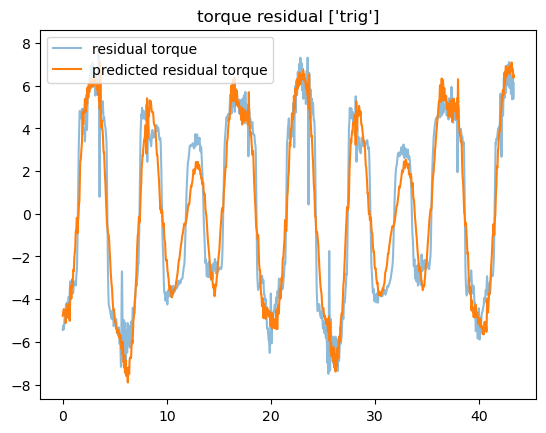

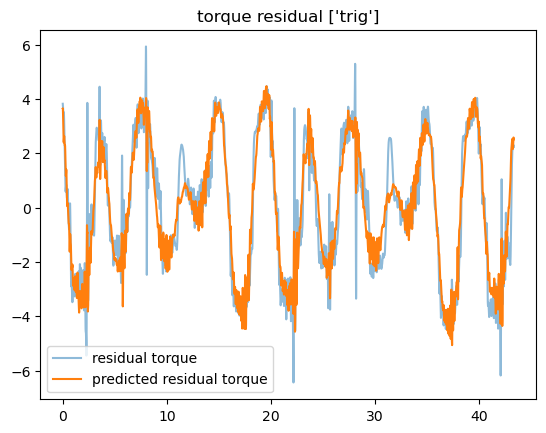

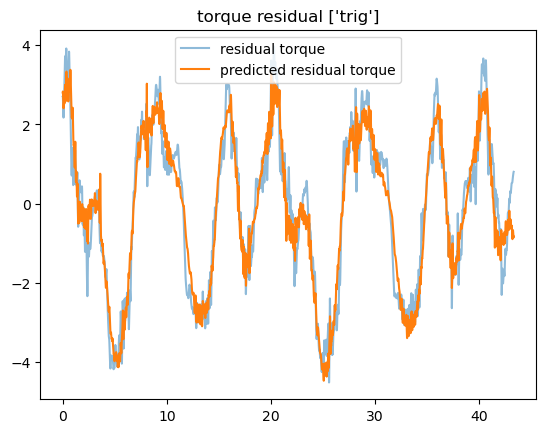

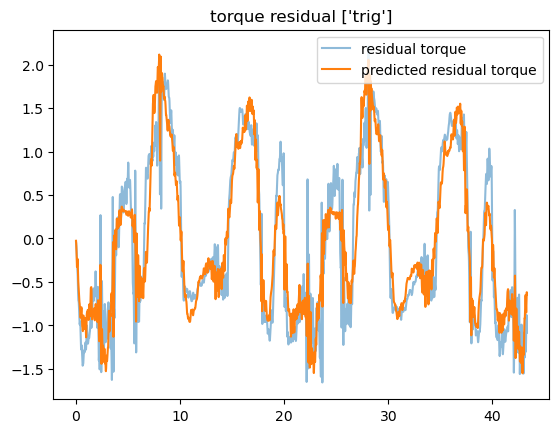

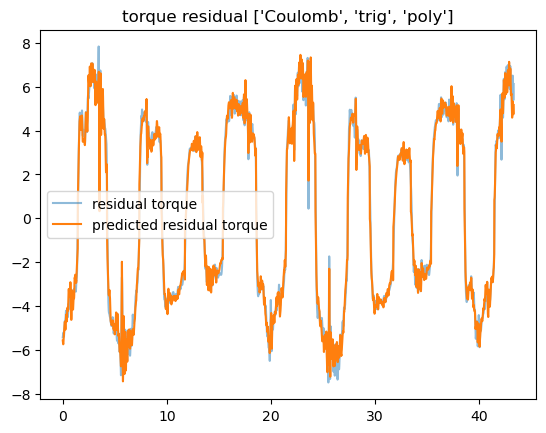

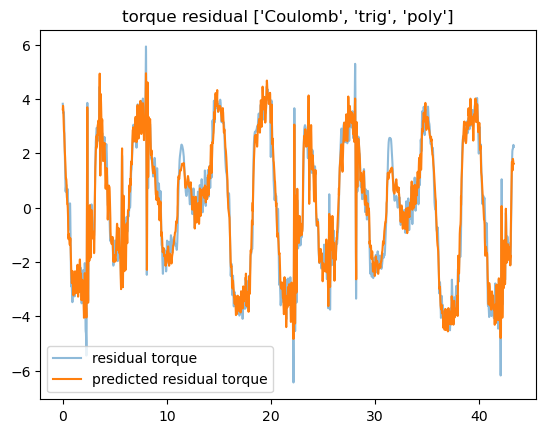

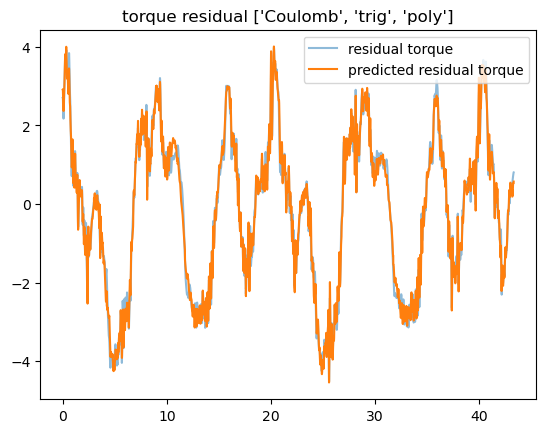

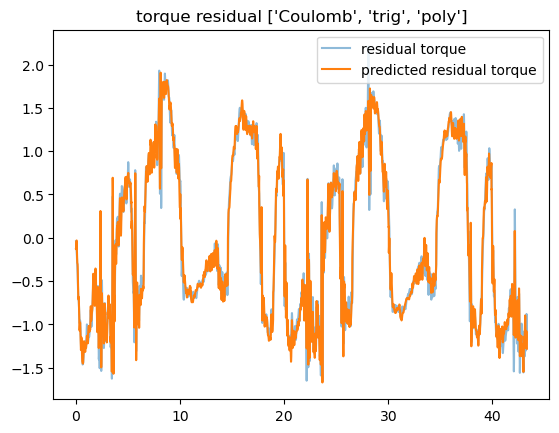

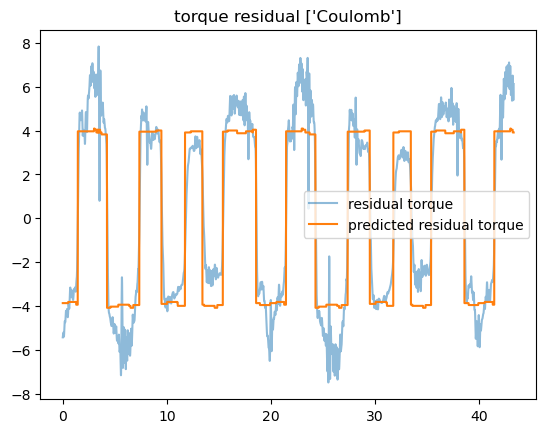

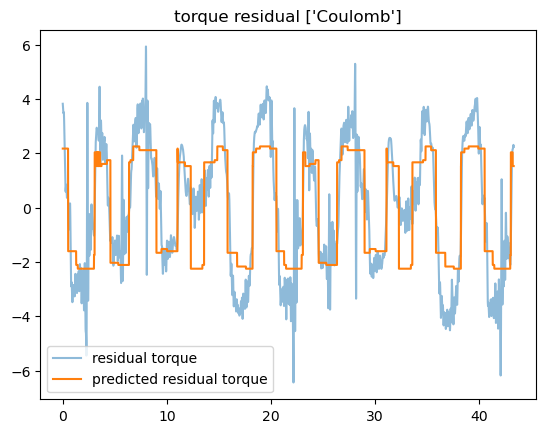

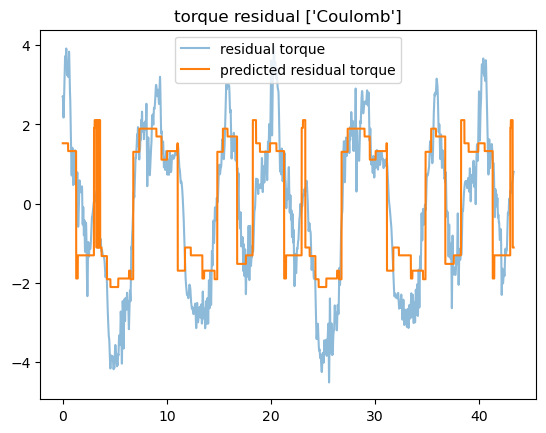

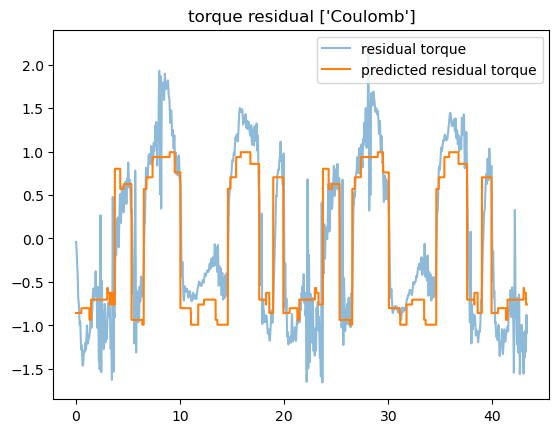

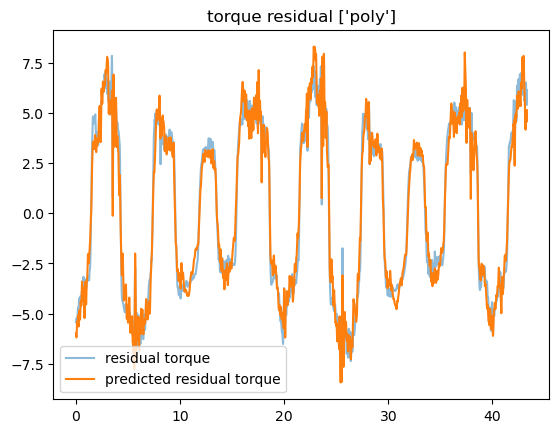

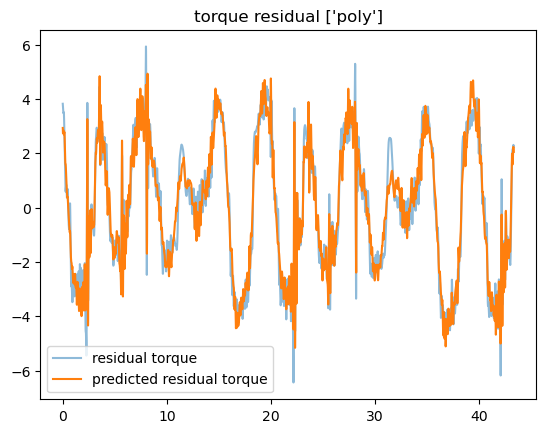

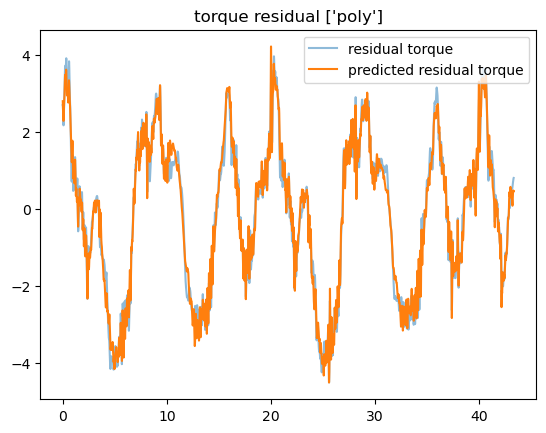

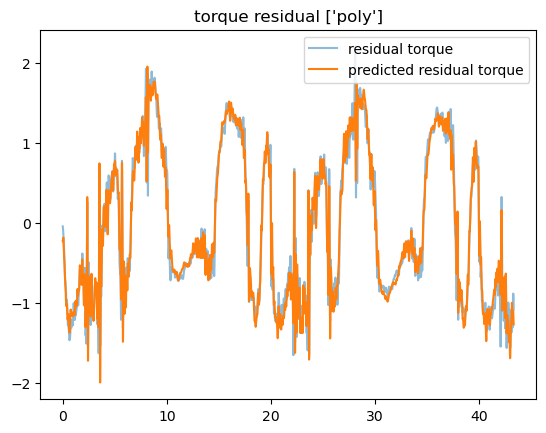

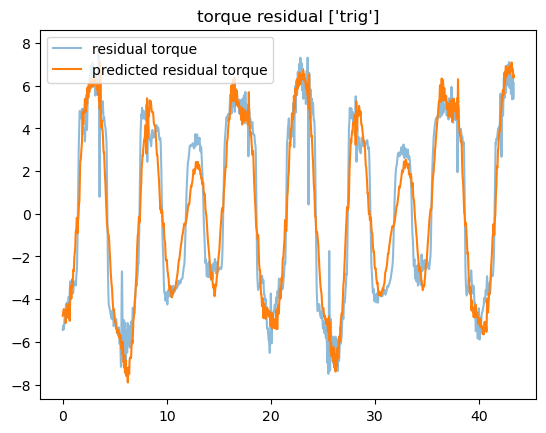

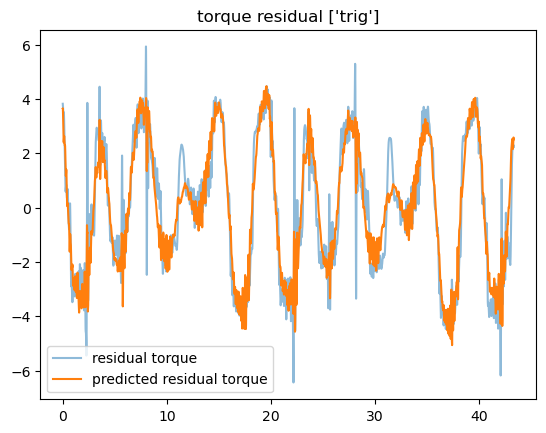

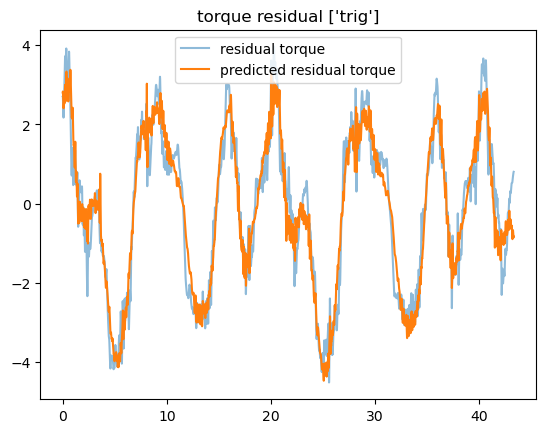

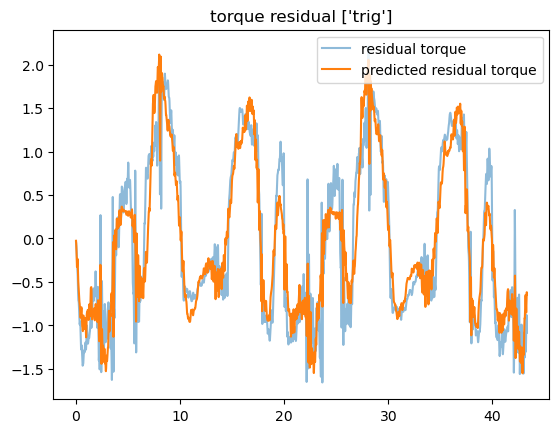

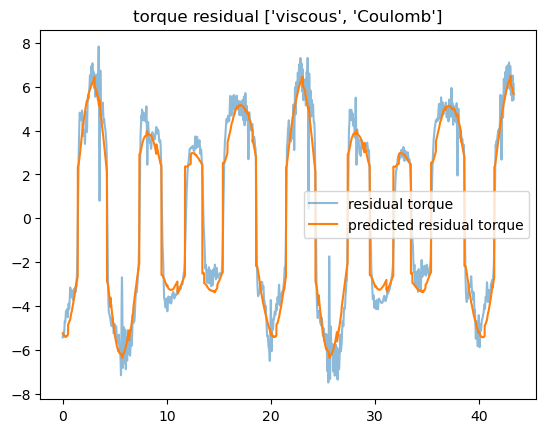

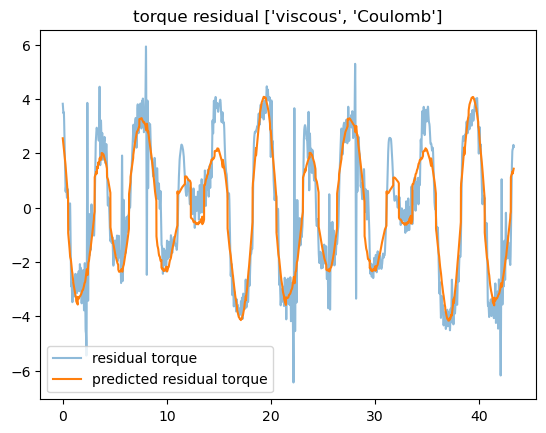

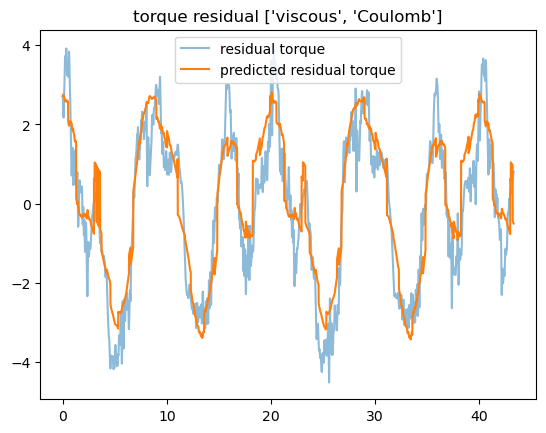

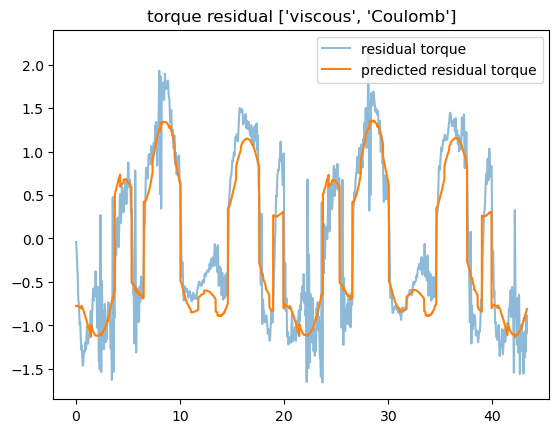

In [206]:
plot_trials_residuals()

#################################################
['trig']
#################################################
tau_rbd.shape (10829, 4)
tau_vec.shape (10829, 4)


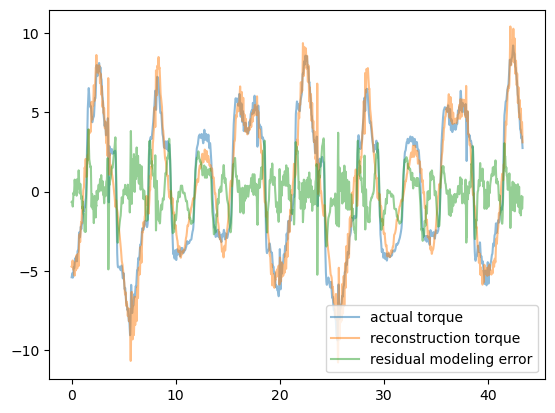

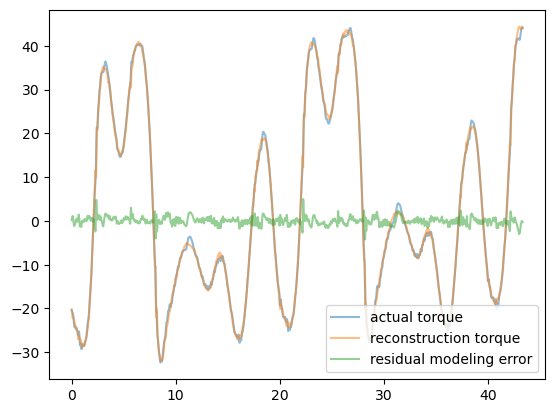

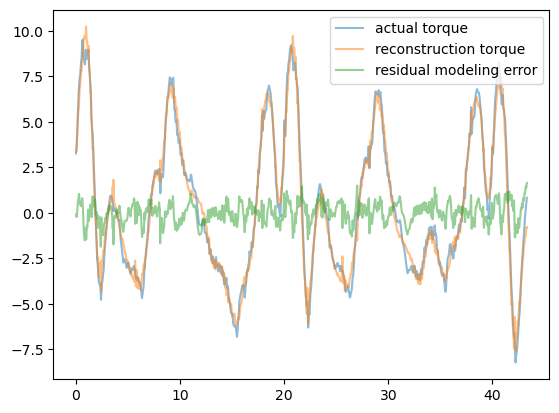

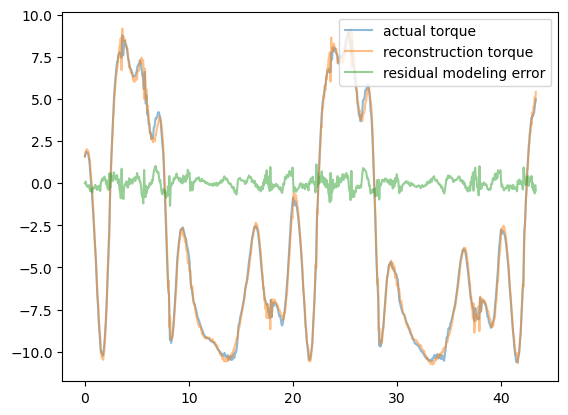

#################################################
['Coulomb', 'trig', 'poly']
#################################################
tau_rbd.shape (10829, 4)
tau_vec.shape (10829, 4)


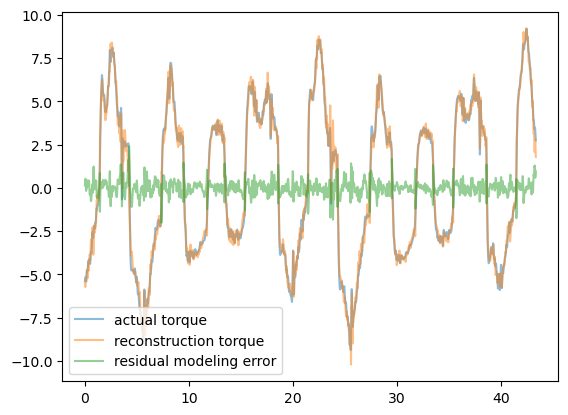

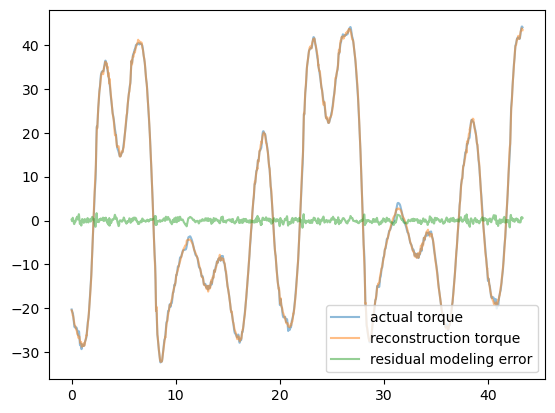

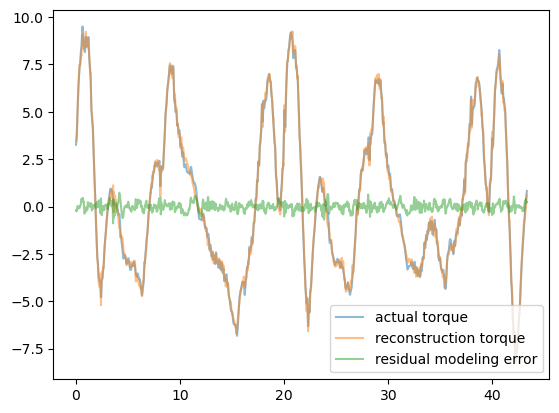

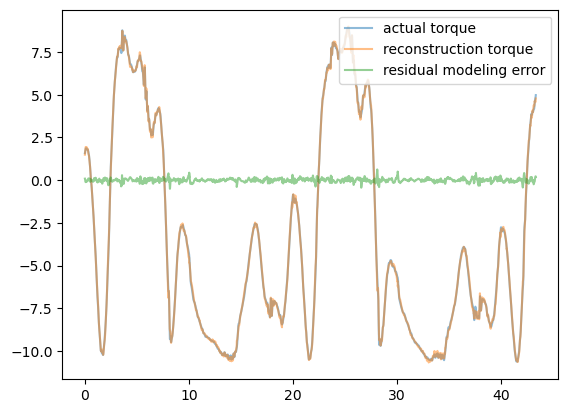

#################################################
['Coulomb']
#################################################
tau_rbd.shape (10829, 4)
tau_vec.shape (10829, 4)


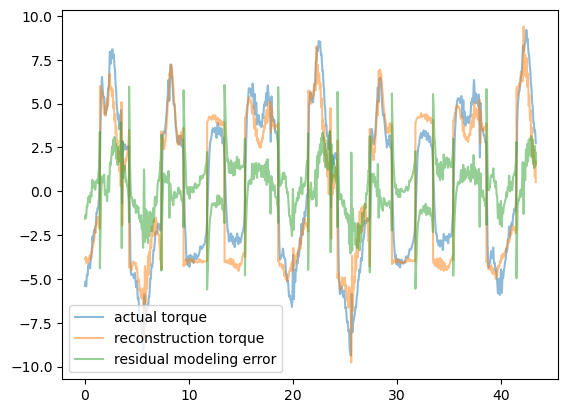

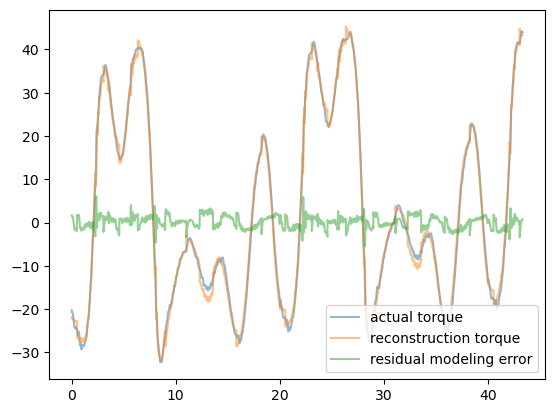

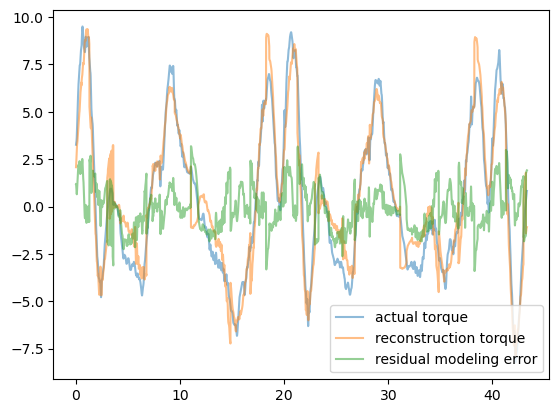

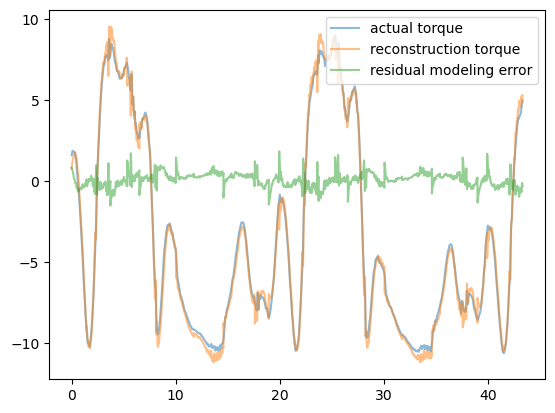

#################################################
['poly']
#################################################
tau_rbd.shape (10829, 4)
tau_vec.shape (10829, 4)


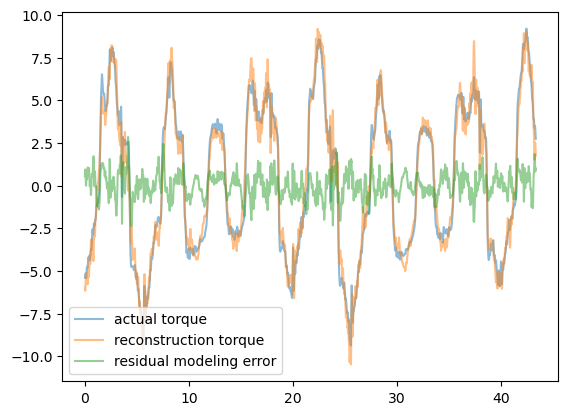

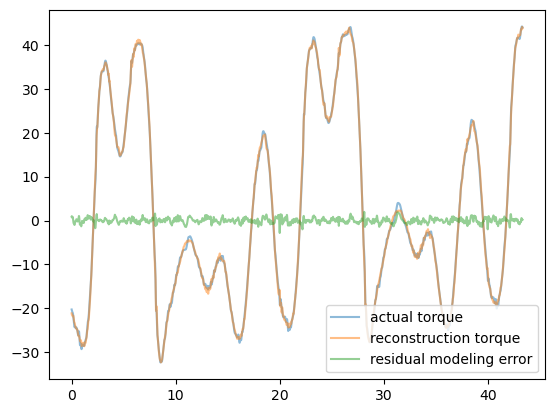

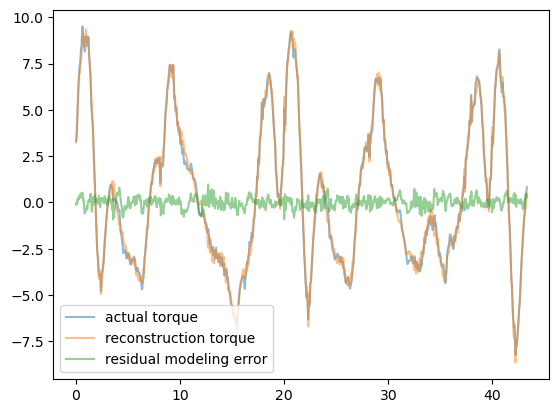

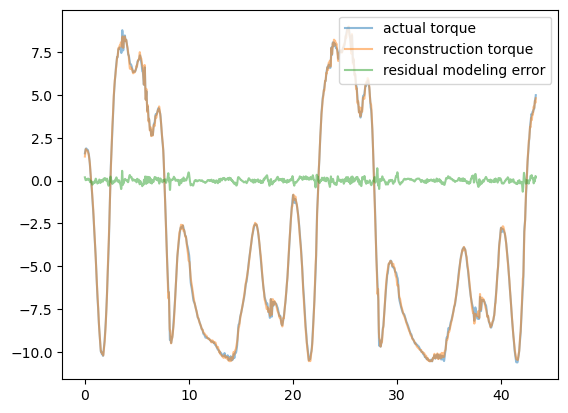

#################################################
['trig']
#################################################
tau_rbd.shape (10829, 4)
tau_vec.shape (10829, 4)


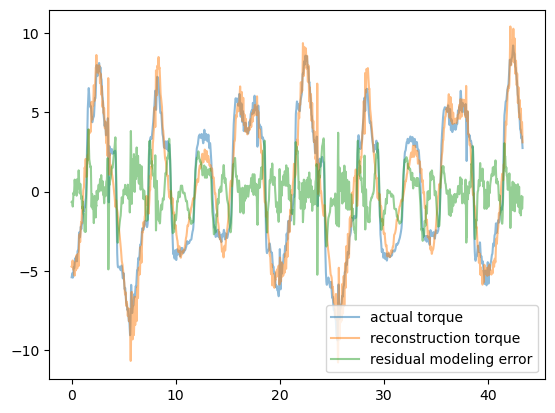

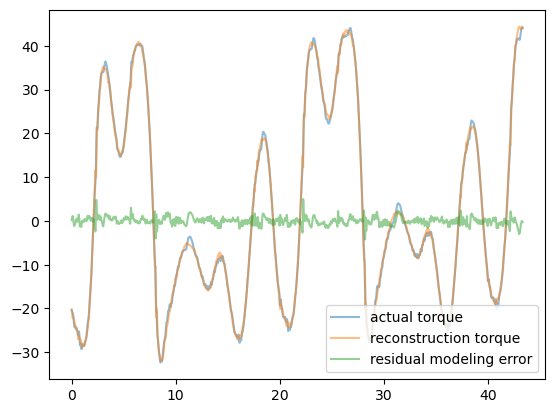

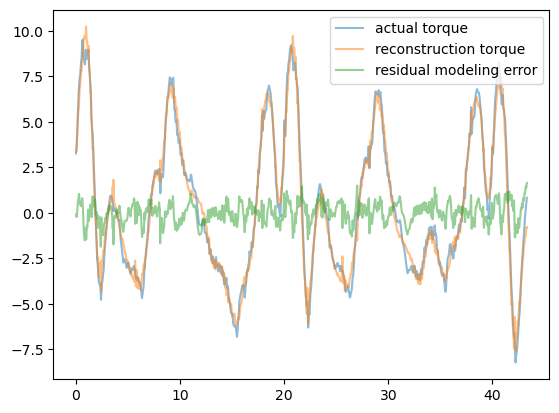

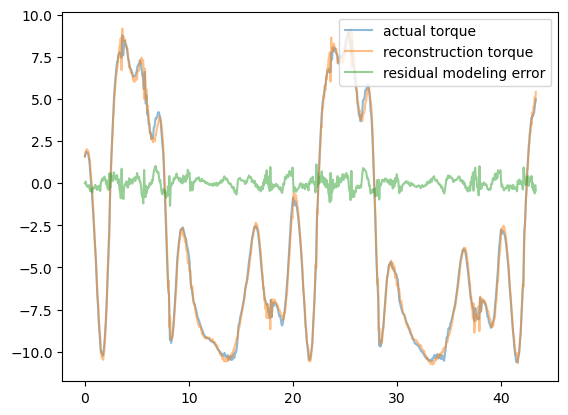

#################################################
['viscous', 'Coulomb']
#################################################
tau_rbd.shape (10829, 4)
tau_vec.shape (10829, 4)


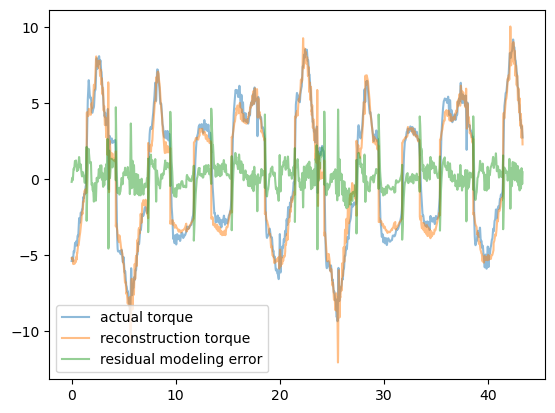

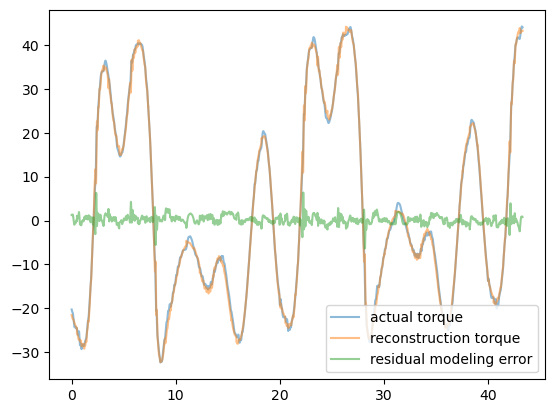

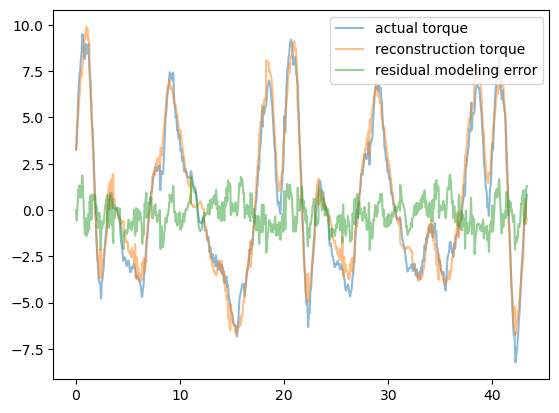

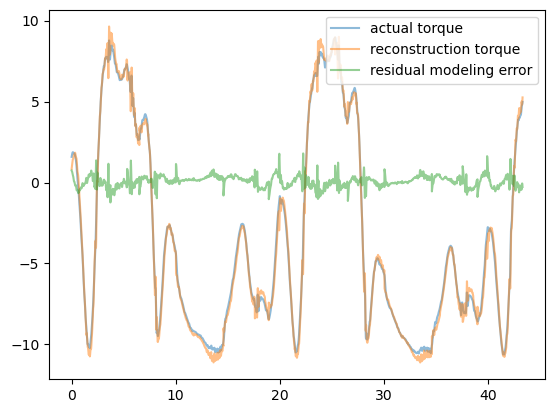

In [207]:
#############################
### PLOT TRIALS RESIDUALS ###
#############################
for i in range(len(trials_tau_residual_hat)):
    tau_residual_prediction = trials_tau_residual_hat[i]
    
    print("#################################################")
    print(trials_basis_type[i])
    print("#################################################")
    tau_vec = tau_vec.reshape(-1,rbt.dof)
    tau_rbd = tau_rbd.reshape(-1,rbt.dof)
    tau_residual = tau_residual.reshape(-1,rbt.dof)
    tau_residual_prediction = tau_residual_prediction.reshape(-1,rbt.dof)
    plot_reconstruction_and_residuals(tau_residual_prediction, tau_residual, tau_rbd, tau_vec)
  
        

In [208]:
for i in range(rbt.dof):
    print(f"RMSE: {np.sqrt(np.mean(np.square(tau_residual.reshape(-1,rbt.dof)[:,i])))}")

RMSE: 4.218293290224343
RMSE: 2.4133050281826574
RMSE: 1.9549514753604933
RMSE: 0.9198174940659323


## A Friction-model-based Framework for Reinforcement Learning of Robotic Tasks in Non-rigid Environments (FFRL_RT_NRE)
Colome et al

This paper uses a novel friction model for each of the joints of the robot:
>>
F^{i}_{fric} = 
 b1 * qi + b2 * dqi + b3 * atan(s * dqi ̇+ z * sign(ddqi))
+0.5 * (1 + sign(dqi))(b4 * f1 + b5 * f2 + b6 * f3 + b7 * f4 + b8 * f5)
+0.5(1 − sign(dqi))(b9 * f1 + b10 * f2 + b11 * f3 + b12 * f4 + b13 * f5),
for i = 1..7,


where 
>>
f_j = (4/pi) * sin((2*j - 1) * h * qi) / (2 * j - 1), j=1..5
are sine Fourier basis functions.

AX=B
A: N, basis_size
X: basis_size, dof
B: N, dof ==> B is the predicted torques, where B[:,j] for each j in range(dof) is the torque for each joint


In [209]:
# get the velocities and accelerations
q, dq, ddq, tau = diff_and_filt_data(dof=rbt.dof, h=rec_h,  q_raw=q_raw, tau_raw=tau_raw,
                               fc_q=fc_q, fc_dq=fc_dq, fc_ddq=fc_ddq, fc_tau=fc_tau)

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
# from sklearn.metrics import root_mean_squared_error

print(q.shape)
print(dq.shape)
print(ddq.shape)
print(tau.shape)
print(tau_residual.shape)

# reset the trials logging
trials_rmse = [] #the error between tau_residual and tau_residual_pred (float)
trials_beta = [] #the regressor vector used (each trial may have a different size of regressor vector)
trials_basis_type = []
trials_tau_residual_hat = []
trials_params_count = []

import sympy as sp
symbols = sp.symbols('ddq, dq, q')


(10829, 4)
(10829, 4)
(10829, 4)
(10829, 4)
(10829, 4)


In [32]:
symbols

(ddq, dq, q)

In [58]:
# FFRL_RT_NRE_basis_3
##### Friction is modeled with an initial model as Fifric = b1 * atan(s * dqi) + b2 * dqi)
from sympy import atan

best_J = np.inf
best_s = None
best_b = None
s_grid = np.linspace(20,200,100)

F= tau_residual.reshape(-1,rbt.dof)

# find the best s value
for s in s_grid:   # log-spaced positive values
    X = np.column_stack([np.arctan(s * dq), dq])
    b, *_ = np.linalg.lstsq(X, F, rcond=None)
    J = np.sqrt(np.mean(np.square(F - X @ b)))
    
    if J < best_J:
        best_J = J
        best_s = s
        best_b = b

# print("s_grid:", s_grid)
print("best s:", best_s)
print("best J:", best_J)
print("best b:", best_b)

ddq_symbol = symbols[0]
dq_symbol = symbols[1]
q_symbol = symbols[2]

FFRL_RT_NRE_basis_3 = [atan(best_s*dq_symbol), dq_symbol]

trial(basis_in=FFRL_RT_NRE_basis_3, symbols=symbols)
trials_basis_type[-1]='FFRL_RT_NRE_basis_3'
trials_params_count.append(2*rbt.dof)

chunks_tau_residual_pred = np.array_split(tau_residual-trials_tau_residual_hat[-1], rbt.dof)
rmse_joint_0 = np.sqrt(np.mean(np.square(chunks_tau_residual_pred[0])))
print("RMSE joint 0:", rmse_joint_0)

##### CONS: "This model not only is independent from position but has no hysteresis value"

best s: 56.36363636363636
best J: 0.5845897264436931
best b: [[ 1.84324893e+00  3.23999613e-01  2.66060620e-04  1.26429633e-01]
 [-1.11480547e-01  6.44245185e-01  2.08011360e-01 -1.93031034e-02]
 [ 4.95583808e-02  2.10173039e-01  5.09530715e-01  4.38773959e-04]
 [ 9.31311472e-02  4.25979804e-02 -4.19813114e-02  4.97836665e-01]
 [ 1.58110322e+00 -3.69366669e-01 -7.29664726e-02 -2.64360617e-01]
 [ 5.85326862e-01  2.55094103e+00 -9.72451550e-01 -1.39552779e-01]
 [-7.29407151e-02 -7.68231775e-01  1.68486414e+00  6.21238403e-02]
 [-5.23387148e-01 -4.82452266e-01  3.81923350e-01  2.95232961e-01]]
Phi.shape (10829, 8)
tau_res.shape (10829, 4)
tau_residual_hat [[-4.68499589  2.49861572  2.48292846  0.11769306]
 [-4.69853637  2.47504905  2.48157829  0.08274707]
 [-4.71177542  2.45129292  2.48037925  0.04769428]
 ...
 [ 4.81999625  1.94535899  0.1865434  -1.03932346]
 [ 4.82403739  1.95410077  0.18295361 -1.04143555]
 [ 4.82793862  1.96207237  0.18009694 -1.04342832]]
beta_hat [[ 1.84324893e+00 

In [65]:
# FFRL_RT_NRE_basis_4
##### Hysteresis is added; acceleration is considered

import numpy as np
import sympy as sp
# utilize scipy least squares
from scipy.optimize import least_squares

tau_residual = tau_residual.reshape(-1,rbt.dof)
joint_params = []

#residual function
def residual_function(params, inputs, outputs):
    b1, b2, s, z = params
    ddq, dq = inputs
    prediction = b1 * np.arctan(s * dq + z * np.sign(ddq)) + b2 * dq
    prediction=prediction.reshape(-1,1)
    return np.ravel(prediction - outputs)

initial_guesses = np.random.uniform(-100,100,(100,4))


for j in range(rbt.dof):
    best_cost_j = np.inf
    best_params_j = None

    inputs = (ddq[:, j], dq[:, j])
    outputs = tau_residual[:, j]
    print(tau_residual.shape)
    print(outputs.shape)

    for ig in initial_guesses:
        res = least_squares(residual_function, ig, args=(inputs, outputs))
        if res.cost < best_cost_j:
            best_cost_j = res.cost
            best_params_j = res.x.copy()

    joint_params.append(best_params_j)

joint_params = np.array(joint_params)
print("joint params:", joint_params)

import numpy as np
tau_residual=tau_residual.reshape(-1,rbt.dof)
N, dof = tau_residual.shape
tau_pred = np.zeros_like(tau_residual, dtype=float).reshape(-1,dof)
print("tau_pred shape:", tau_pred.shape)
print("tau_pred[:,0] shape:", tau_pred[:,0].shape)

for j in range(dof):
    b1_j, b2_j, s_j, z_j = joint_params[j]

    dq_j = dq[:, j]
    ddq_j = ddq[:, j]

    tau_pred[:, j] = (
        b1_j * np.arctan(s_j * dq_j + z_j * np.sign(ddq_j))
        + b2_j * dq_j
    ).reshape(-1,1)

print(tau_residual.shape)
    
rmse_total = np.sqrt(np.mean(np.square((tau_residual - tau_pred))))

trials_rmse.append(rmse_total)
trials_basis_type.append('FFRL_RT_NRE_basis_4')
trials_params_count.append(joint_params.size)
trials_tau_residual_hat.append(tau_pred.reshape(-1,rbt.dof))

chunks_tau_residual_pred = np.array_split(tau_residual-tau_pred, rbt.dof)
rmse_joint_0 = np.sqrt(np.mean(np.square(chunks_tau_residual_pred[0])))
print("RMSE joint 0:", rmse_joint_0)


print("total RMSE:", rmse_total)

(10829, 4)
(10829, 1)
(10829, 4)
(10829, 1)
(10829, 4)
(10829, 1)
(10829, 4)
(10829, 1)
joint params: [[ 1.72586592e+00  1.62256024e+00  1.16511463e+02 -9.10325221e-01]
 [-6.82643499e+00 -2.90583098e+00 -1.26400159e+00 -5.09543629e-03]
 [ 7.60013639e+00 -3.77883780e+00  1.08669100e+00 -1.16225664e-02]
 [-5.03915319e-01  2.44642769e-01 -7.10476242e+01  1.18861109e+00]]
tau_pred shape: (10829, 4)
tau_pred[:,0] shape: (10829, 1)
(10829, 4)
RMSE joint 0: 0.5751218673572596
total RMSE: 0.601010219915819


In [157]:
joint_params.size

16

In [220]:
# FFRL_RT_NRE_basis_5

import numpy as np

def sine_fourier_basis(q, h, n_terms=5): # generated for one joint
    # print(q)
    q = np.asarray(q).reshape(-1)
    cols = []
    for j in range(1, n_terms + 1):
        fj = (4 / np.pi) * np.sin((2*j - 1) * h * q) / (2*j - 1)
        cols.append(fj[:, None])
    return np.hstack(cols)   # shape (N, n_terms) # [f1, f2, f3, f4, f5]

In [159]:
# FFRL_RT_NRE_basis_5

def gated_sine_fourier_basis(q, dq, h, n_terms=5): # in the paper they indicate that seperate fourier basis necessary for sign of velocity
    q = np.asarray(q).reshape(-1)
    dq = np.asarray(dq).reshape(-1)

    F = sine_fourier_basis(q, h, n_terms=n_terms)   # (N, 5)

    g_pos = 0.5 * (1 + np.sign(dq))   # (N,)
    g_neg = 0.5 * (1 - np.sign(dq))   # (N,)

    F_pos = F * g_pos[:, None]
    F_neg = F * g_neg[:, None]

    return F_pos, F_neg

In [160]:
# FFRL_RT_NRE_basis_5

def build_advanced_friction_regressor(q, dq, ddq, s, z, h, n_terms=5):
    q = np.asarray(q).reshape(-1)
    dq = np.asarray(dq).reshape(-1)
    ddq = np.asarray(ddq).reshape(-1)

    atan_col = np.arctan(s * dq + z * np.sign(ddq))[:, None]
    q_col = q[:, None]
    dq_col = dq[:, None]

    F_pos, F_neg = gated_sine_fourier_basis(q, dq, h, n_terms=n_terms)

    X = np.hstack([
        q_col,          # b1
        dq_col,         # b2
        atan_col,       # b3
        F_pos,          # b4...b8
        F_neg           # b9...b13
    ])
    return X

In [161]:
# FFRL_RT_NRE_basis_5

'''
for grid in values get the somewhat estimate of h,s,z for each joint. then we can do scipy optimize around that area for each joint.
below is the function to do so for ONE joint
'''

def single_joint_torque_compute_FFRL_RT_NRE_basis_5(q, dq, ddq, B, n_fourier_terms=5):
    '''returns the appropriate h,s,z for that one joint. make sure you slice q,dq,ddq, and tau_residual as B'''
    z_grid = np.linspace(0,5,10)
    s_grid = np.linspace(0,100,10)
    h_grid = np.linspace(-10,10,10)
    best_rmse = np.inf
    for z in z_grid:
        for s in s_grid:
            for h in h_grid:
                X = build_advanced_friction_regressor(q, dq, ddq, s, z, h, n_terms=n_fourier_terms)
                # print("X shape:", X.shape) # should be (N, 13), if N is the number of joint samples, counting each joint config as 1 sample
                # AX=B
                b , *_ = np.linalg.lstsq(X, B, rcond=None)
                pred = X@b
                rmse = np.sqrt(np.mean(np.square(B - pred)))
                # print("X shape:", X.shape)   # should be (N, 13)
                # print("b shape:", b.shape)   # should be (13,)
                # print("rmse:", rmse)
                if rmse < best_rmse:
                    best_rmse = rmse
                    best_h = h
                    best_z = z
                    best_s = s
                    best_b = b.copy()

    # now stage 2: found the best in the grid, now use scipy optimize to hone in
    #residual function
    def residual_function(params, inputs, outputs):
        b1, b2, b3, b4, b5, b6, b7, b8, b9, b10, b11, b12, b13, s, z, h = params
        b_vec = np.array([b1, b2, b3, b4, b5, b6, b7, b8, b9, b10, b11, b12, b13])
        ddq, dq, q = inputs
        X = build_advanced_friction_regressor(q, dq, ddq, s, z, h, n_terms=n_fourier_terms)
        prediction = np.dot(X,b_vec)
        prediction=prediction.reshape(-1,1)
        # print(prediction)
        # print("prediction shape:", prediction.shape)
        
        return np.ravel(prediction - outputs)

    initial_guess = (*best_b, best_s, best_z, best_h)
    inputs = (ddq, dq, q)
    outputs = B
    res = least_squares(residual_function, initial_guess, args=(inputs, outputs))
    best_params_j = res.x.copy()

    b1, b2, b3, b4, b5, b6, b7, b8, b9, b10, b11, b12, b13, s, z, h = best_params_j
    b = np.array([b1, b2, b3, b4, b5, b6, b7, b8, b9, b10, b11, b12, b13])

    X = build_advanced_friction_regressor(q, dq, ddq, s, z, h, n_terms=n_fourier_terms)
    
    prediction = np.dot(X,b)
    
    return best_params_j, prediction
    


In [162]:
# FFRL_RT_NRE_basis_5
tau_residual = tau_residual.reshape(-1, rbt.dof)

tau_residual=tau_residual.reshape(-1,rbt.dof)
N, dof = tau_residual.shape
tau_pred = np.zeros_like(tau_residual, dtype=float).reshape(-1,dof)
print("tau_pred shape:", tau_pred.shape)
print("tau_pred[:,0] shape:", tau_pred[:,0].shape)

params=[]
for j in range(dof):
    q_j = q[:, j]
    dq_j = dq[:, j]
    ddq_j = ddq[:, j]
    F_j = tau_residual[:, j]
    best_params_j, prediction = single_joint_torque_compute_FFRL_RT_NRE_basis_5(q_j, dq_j, ddq_j, F_j)
    if best_params_j is None:
        raise ValueError(f"No valid params found for joint {j}")
    print("best params:\n",best_params_j.shape)
    params.append(best_params_j)
    tau_pred[:, j] = np.asarray(prediction).reshape(-1,1)

params = np.array(params).ravel()
tau_pred = tau_pred.reshape(-1,1)
tau_residual=tau_residual.reshape(-1,1)
rmse_total = np.sqrt(np.mean(np.square((tau_residual - tau_pred))))

chunks_tau_residual_pred = np.array_split(tau_residual-tau_pred, rbt.dof)
rmse_joint_0 = np.sqrt(np.mean(np.square(chunks_tau_residual_pred[0])))

trials_rmse.append(rmse_total)
trials_basis_type.append('FFRL_RT_NRE_basis_5')
trials_params_count.append(len(params))
trials_tau_residual_hat.append(tau_pred.reshape(-1,rbt.dof))

print("total RMSE:", rmse_total)
print("RMSE joint 0:", rmse_joint_0)

tau_pred shape: (10829, 4)
tau_pred[:,0] shape: (10829, 1)


/home/oliveoil/miniconda3/envs/id/lib/python3.8/site-packages/numpy/lib/type_check.py:340: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  type_ = asarray(x).dtype.type
/home/oliveoil/miniconda3/envs/id/lib/python3.8/site-packages/numpy/core/shape_base.py:65: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  ary = asanyarray(ary)


best params:
 (16,)
best params:
 (16,)
best params:
 (16,)
best params:
 (16,)
total RMSE: 0.7475854168452922
RMSE joint 0: 0.7964931548419946


In [66]:
trials_rmse

[0.5845897264436932, 0.5845897264436932, 0.601010219915819]

In [35]:
trials_params_count

[8]

In [36]:
trials_tau_residual_hat

[matrix([[-4.68499589,  2.49861572,  2.48292846,  0.11769306],
         [-4.69853637,  2.47504905,  2.48157829,  0.08274707],
         [-4.71177542,  2.45129292,  2.48037925,  0.04769428],
         ...,
         [ 4.81999625,  1.94535899,  0.1865434 , -1.03932346],
         [ 4.82403739,  1.95410077,  0.18295361, -1.04143555],
         [ 4.82793862,  1.96207237,  0.18009694, -1.04342832]])]

#################################################
FFRL_RT_NRE_basis_3
#################################################
tau_rbd.shape (10829, 4)
tau_vec.shape (10829, 4)


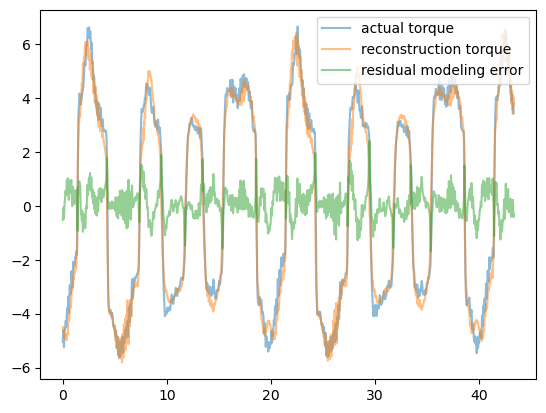

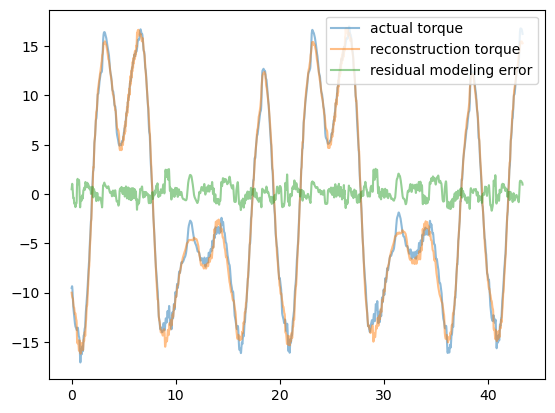

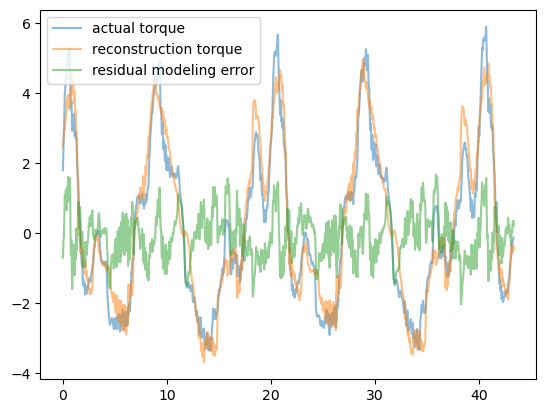

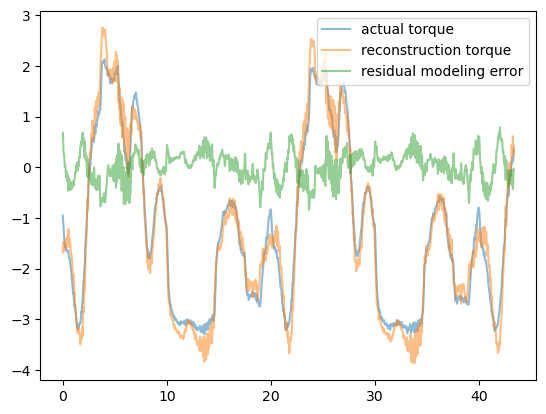

#################################################
FFRL_RT_NRE_basis_3
#################################################
tau_rbd.shape (10829, 4)
tau_vec.shape (10829, 4)


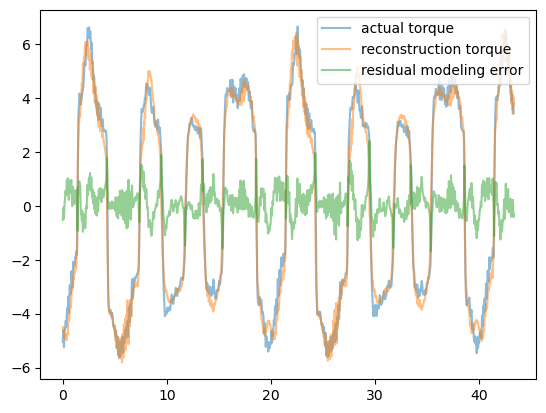

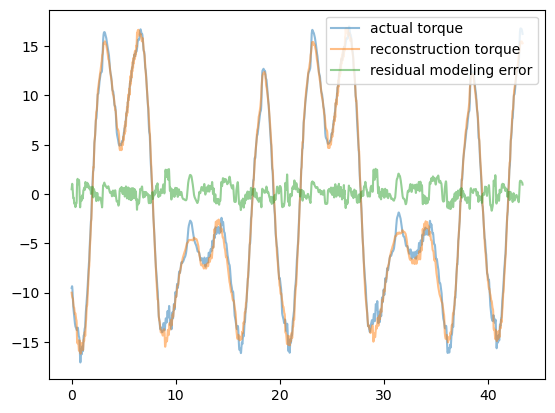

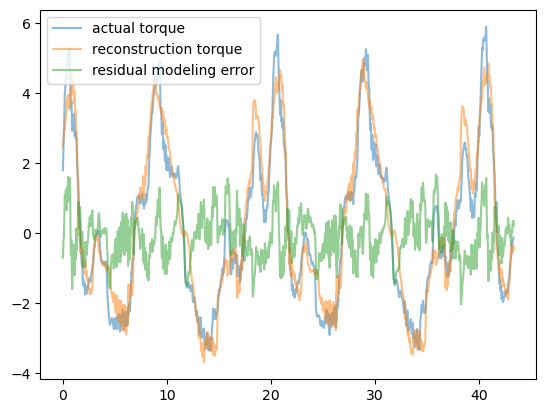

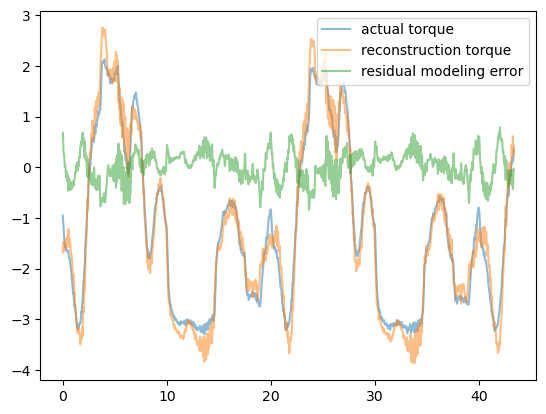

#################################################
FFRL_RT_NRE_basis_4
#################################################
tau_rbd.shape (10829, 4)
tau_vec.shape (10829, 4)


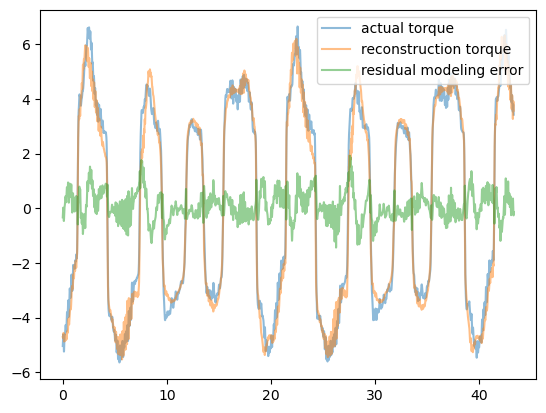

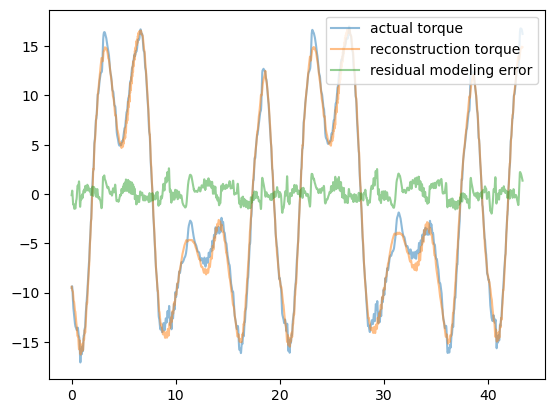

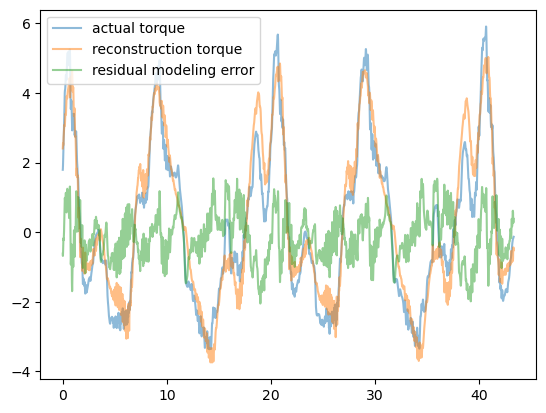

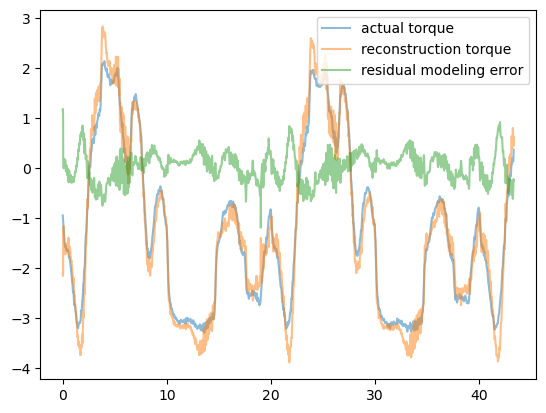

In [67]:
#############################
### PLOT TRIALS RESIDUALS ###
#############################
for i in range(len(trials_tau_residual_hat)):
    tau_residual_prediction = trials_tau_residual_hat[i]
    
    print("#################################################")
    print(trials_basis_type[i])
    print("#################################################")
    tau_vec = tau_vec.reshape(-1,rbt.dof)
    tau_rbd = tau_rbd.reshape(-1,rbt.dof)
    tau_residual = tau_residual.reshape(-1,rbt.dof)
    tau_residual_prediction = tau_residual_prediction.reshape(-1,rbt.dof)
    plot_reconstruction_and_residuals(tau_residual_prediction, tau_residual, tau_rbd, tau_vec)
  
        

In [63]:
for i in range(rbt.dof):
    print(np.sqrt(np.mean(np.square(tau_residual[:,i]-tau_residual_prediction[:,i]))))

0.5285760993859524
0.762511478676535
0.6544621614173773
0.27900434471778107


# SINDy Methods and Hybrid SINDy

install using `pip install pysindy`
import using `import pysindy as ps`

We use the SINDy library not to solve dynamic equations, but simply for the sparse symbolic regression aspect.

# Sparse Functional Regression
This method is essentially SINDy but without the actual ODE part

In [210]:
'''
PSUEDOCODE:

symbols=(q_symbol, dq_symbol, ddq_symbol)
basis_in = [q_symbol, dq_symbol, q_symbol**2, sp.sign(dq_symbol), etc ] # list of sympy expressions 

rmse_vals=[]
lambda_vals = np.linspace(0,1,n)
weight_vectors = []

for lambda in lambda_vals:
    Phi = generate_regressor(q, dq, ddq, custom_basis_function=basis_in, symbols=symbols)
    w, *_ = np.linalg.lstsq(Phi, b, rcond=None)
    w_sparse = [w_i if w_i <= lambda else 0 for w_i in w]
    b_hat = Phi @ w_hat
    RMSE = rmse(b,b_hat)
    rmse_vals.append(RMSE)
    weight_vectors.append(w_sparse)

# then we want to get the symbolic basis that each w represents
for each w in weight_vectors:
    mask = [1 if w_i else 0 for w_i in w]
    activated_basis_terms = mask && basis_in # should be something like [q_symbol, 0, dq_symbol, 0, 0, ..] etc
    print activated_basis_terms

generate a pareto plot:
plt.plot(lambda_vals, rmse_vals)

choose the best point on the pareto plot (the elbow)
'''


'\nPSUEDOCODE:\n\nsymbols=(q_symbol, dq_symbol, ddq_symbol)\nbasis_in = [q_symbol, dq_symbol, q_symbol**2, sp.sign(dq_symbol), etc ] # list of sympy expressions \n\nrmse_vals=[]\nlambda_vals = np.linspace(0,1,n)\nweight_vectors = []\n\nfor lambda in lambda_vals:\n    Phi = generate_regressor(q, dq, ddq, custom_basis_function=basis_in, symbols=symbols)\n    w, *_ = np.linalg.lstsq(Phi, b, rcond=None)\n    w_sparse = [w_i if w_i <= lambda else 0 for w_i in w]\n    b_hat = Phi @ w_hat\n    RMSE = rmse(b,b_hat)\n    rmse_vals.append(RMSE)\n    weight_vectors.append(w_sparse)\n\n# then we want to get the symbolic basis that each w represents\nfor each w in weight_vectors:\n    mask = [1 if w_i else 0 for w_i in w]\n    activated_basis_terms = mask && basis_in # should be something like [q_symbol, 0, dq_symbol, 0, 0, ..] etc\n    print activated_basis_terms\n\ngenerate a pareto plot:\nplt.plot(lambda_vals, rmse_vals)\n\nchoose the best point on the pareto plot (the elbow)\n'

In [211]:
import numpy as np

def correlation_groups(C, thresh=0.995):
    """
    C: correlation matrix (n x n)
    returns: list of lists (each = indices of one correlated group)
    """
    n = C.shape[0]
    visited = np.zeros(n, dtype=bool)
    groups = []

    for i in range(n):
        if visited[i]:
            continue

        stack = [i]
        group = []

        while stack:
            j = stack.pop()
            if visited[j]:
                continue

            visited[j] = True
            group.append(j)

            # find neighbors strongly correlated with j
            neighbors = np.where(np.abs(C[j]) >= thresh)[0]

            for k in neighbors:
                if not visited[k]:
                    stack.append(k)

        groups.append(sorted(group))

    return groups

def groups_to_mask(groups, n):
    mask = np.zeros(n, dtype=bool)
    for g in groups:
        mask[g[0]] = True   # keep first
    return mask

def groups_to_mask_by_variance(groups, Phi):
    mask = np.zeros(Phi.shape[1], dtype=bool)

    for g in groups:
        stds = [np.std(Phi[:, j]) for j in g]
        keep = g[np.argmax(stds)]
        mask[keep] = True

    return mask

def correlation_prune_mask(Phi, thresh=0.995):
    # normalize (important)
    Phi = np.asarray(Phi, dtype=float)
    std = Phi.std(axis=0)
    std[std == 0] = 1.0
    Phi_n = Phi / std

    C = np.corrcoef(Phi_n, rowvar=False)

    groups = correlation_groups(C, thresh)

    mask = groups_to_mask_by_variance(groups, Phi)

    return mask, groups

In [212]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import itertools
# --------------------------
# helpers
# --------------------------

def generate_polynomial_basis(symbols, degree):
    # basis = [1]  # include bias
    basis=[]
    n = len(symbols)

    for deg in range(1, degree + 1):
        for combo in itertools.combinations_with_replacement(range(n), deg):
            term = 1
            for idx in combo:
                term *= symbols[idx]
            basis.append(term)

    return basis

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    return np.sqrt(np.mean((y_true - y_pred) ** 2))
    
def pick_elbow(lambda_vals, rmse_vals, nnz_vals):
    """
    Simple elbow heuristic:
    choose the point closest to the lower-left corner
    after normalizing complexity and error.
    """
    x = np.asarray(nnz_vals, dtype=float)
    y = np.asarray(rmse_vals, dtype=float)

    x_norm = (x - x.min()) / (x.max() - x.min() + 1e-12)
    y_norm = (y - y.min()) / (y.max() - y.min() + 1e-12)

    score = np.sqrt(x_norm**2 + y_norm**2)
    return np.argmin(score)


def activated_basis_from_weights(w, basis, tol=1e-10):
    return [term for wi, term in zip(w, basis) if abs(wi) > tol]


def stlsq(Phi, b, lam, n_iter=10):
    Phi = np.asarray(Phi, dtype=float)
    b = np.asarray(b).reshape(-1)

    Phi_scale = np.linalg.norm(Phi, axis=0)
    Phi_scale[Phi_scale < 1e-12] = 1.0
    Phi_n = Phi / Phi_scale

    b_scale = np.linalg.norm(b)
    if b_scale < 1e-12:
        b_scale = 1.0
    b_n = b / b_scale

    w, *_ = np.linalg.lstsq(Phi_n, b_n, rcond=None)
    w = w.reshape(-1)

    prev_active = None

    for _ in range(n_iter):
        active = np.abs(w) >= lam

        if not np.any(active):
            w[:] = 0.0
            break

        w_new = np.zeros_like(w)
        w_new[active], *_ = np.linalg.lstsq(Phi_n[:, active], b_n, rcond=None)
        w_new = w_new.reshape(-1)

        new_active = np.abs(w_new) >= lam
        if prev_active is not None and np.array_equal(new_active, prev_active):
            w = w_new
            break

        w = w_new
        prev_active = new_active

    return b_scale * w / Phi_scale

    
def single_joint_sindy(i, basis_in=None, symbols=None, normalize=True):
    if symbols is None:
        symbols = sp.symbols(('q_symbol', 'dq_symbol', 'ddq_symbol'))

    q_symbol, dq_symbol, ddq_symbol = symbols

    if basis_in is None:
        basis_in = [
            q_symbol,
            dq_symbol,
            ddq_symbol,
            sp.sign(dq_symbol),
            sp.sin(q_symbol),
            sp.sin(dq_symbol),
            sp.sin(ddq_symbol),
        ]

    # --------------------------
    # data
    # --------------------------
    b = np.asarray(tau_residual).reshape(-1, rbt.dof)[:, i]
    q_i = q.reshape(-1, rbt.dof)[:, i]
    dq_i = dq.reshape(-1, rbt.dof)[:, i]
    ddq_i = ddq.reshape(-1, rbt.dof)[:, i]

    Phi = generate_regressor(
        q_i, dq_i, ddq_i,
        custom_basis_function=basis_in,
        symbols=symbols
    )
    Phi = np.asarray(Phi, dtype=float)

    # --------------------------
    # diagnostics on raw Phi
    # --------------------------
    for k, expr in enumerate(basis_in):
        col = Phi[:, k]
        print(k, expr, "mean", np.mean(col), "std", np.std(col), "min", np.min(col), "max", np.max(col))

    # Avoid NaNs from constant columns in corrcoef
    nonconst = Phi.std(axis=0) > 1e-12
    if np.sum(nonconst) > 1:
        C = np.corrcoef(Phi[:, nonconst], rowvar=False)
        print(np.round(C, 3))

    # --------------------------
    # prune correlated columns
    # --------------------------
    mask_prune, groups = correlation_prune_mask(Phi, thresh=0.9)

    Phi = Phi[:, mask_prune]
    basis_in = [basis_in[j] for j in range(len(mask_prune)) if mask_prune[j]]

    print("Kept basis after pruning:")
    print(basis_in)
    print("###############################################")

    print("correlation diagnostics on pruned basis:")

    for k, expr in enumerate(basis_in):
        col = Phi[:, k]
        print(k, expr, "mean", np.mean(col), "std", np.std(col), "min", np.min(col), "max", np.max(col))

    # Avoid NaNs from constant columns in corrcoef
    nonconst = Phi.std(axis=0) > 1e-12
    if np.sum(nonconst) > 1:
        C = np.corrcoef(Phi[:, nonconst], rowvar=False)
        print(np.round(C, 3))

    # --------------------------

    # --------------------------
    # normalize pruned regressor
    # --------------------------
    # if normalize:
    #     # Use column norm or std. Norm is usually better for sparse regression.
    #     Phi_scale = np.linalg.norm(Phi, axis=0)
    #     Phi_scale[Phi_scale < 1e-12] = 1.0
    #     Phi_n = Phi / Phi_scale

    #     b_scale = np.linalg.norm(b)
    #     if b_scale < 1e-12:
    #         b_scale = 1.0
    #     b_n = b / b_scale
    # else:
    #     Phi_scale = np.ones(Phi.shape[1])
    #     b_scale = 1.0
    #     Phi_n = Phi
    #     b_n = b

    # # --------------------------
    # # dense least-squares on normalized system
    # # --------------------------
    # w_dense_n, *_ = np.linalg.lstsq(Phi_n, b_n, rcond=None)
    # w_dense_n = np.asarray(w_dense_n).reshape(-1)

    # # threshold on normalized weights
    # lambda_vals = np.linspace(0.0, np.max(np.abs(w_dense_n)), 50)

    rmse_vals = []
    nnz_vals = []
    weight_vectors = []
    active_basis_list = []
    b_hat_vals = []

    # --------------------------
    # threshold + refit on normalized system
    # --------------------------
    # for lam in lambda_vals:
    #     mask_active = np.abs(w_dense_n) >= lam

    #     if not np.any(mask_active):
    #         w_sparse_n = np.zeros_like(w_dense_n)
    #         w_sparse = np.zeros_like(w_dense_n)
    #         b_hat = np.zeros_like(b)
    #     else:
    #         # Phi_active_n = Phi_n[:, mask_active]
    #         # w_active_n, *_ = np.linalg.lstsq(Phi_active_n, b_n, rcond=None)

    #         # w_sparse_n = np.zeros_like(w_dense_n)
    #         # w_sparse_n[mask_active] = np.asarray(w_active_n).reshape(-1)

    #         # # Convert normalized coefficients back to physical scale
    #         # # b_n = Phi_n @ w_sparse_n
    #         # # b   = b_scale * (Phi / Phi_scale) @ w_sparse_n
    #         # #     = Phi @ (b_scale * w_sparse_n / Phi_scale)
            
    #         # w_sparse = b_scale * w_sparse_n / Phi_scale
    #         w_sparse = stlsq(Phi,b,lam)

    #         b_hat = Phi @ w_sparse

    #     b_hat_vals.append(b_hat)

    #     err = rmse(b, b_hat)
    #     rmse_vals.append(err)
    #     nnz_vals.append(np.count_nonzero(w_sparse))
    #     weight_vectors.append(w_sparse.copy())
    #     active_basis_list.append(activated_basis_from_weights(w_sparse, basis_in))

    lambda_vals = np.linspace(0.01, 0.5, 50)

    for lam in lambda_vals:
        w_sparse = stlsq(Phi, b, lam)
        b_hat = Phi @ w_sparse
    
        b_hat_vals.append(b_hat)
        err = rmse(b, b_hat)
        rmse_vals.append(err)
        nnz_vals.append(np.count_nonzero(np.abs(w_sparse) > 1e-10))
        weight_vectors.append(w_sparse.copy())
        active_basis_list.append(activated_basis_from_weights(w_sparse, basis_in, tol=1e-10))

    # --------------------------
    # print active symbolic basis
    # --------------------------
    for lam, w_sparse, active_terms, rmse_val in zip(lambda_vals, weight_vectors, active_basis_list, rmse_vals):
        print(f"lambda = {lam:.6f}")
        print("weights =", w_sparse)
        print("rmse =", rmse_val)
        print("active basis =", active_terms if active_terms else ["<none>"])
        print()

    # --------------------------
    # pick elbow
    # --------------------------
    best_idx = pick_elbow(lambda_vals, rmse_vals, nnz_vals)

    print("Chosen elbow point")
    print("lambda:", lambda_vals[best_idx])
    print("RMSE:", rmse_vals[best_idx])
    print("nonzero terms:", nnz_vals[best_idx])
    print("active basis:", active_basis_list[best_idx])
    print("weights:", weight_vectors[best_idx])

    return weight_vectors[best_idx], b_hat_vals[best_idx], active_basis_list[best_idx], lambda_vals[best_idx]

In [213]:

symbols = sp.symbols(('q_symbol', 'dq_symbol', 'ddq_symbol'))
symbols = [s for s in symbols]
z=2
poly_symbols = generate_polynomial_basis(symbols, degree=2)
# sin_symbols = [sp.sin(s) for s in symbols]
# cos_symbols = [sp.cos(s) for s in symbols]
sin_symbols=[]
cos_symbols=[]
for i in range(1,z):
    sin_symbols+=[sp.sin(i*s) for s in symbols]
    cos_symbols+=[sp.cos(i*s) for s in symbols]
sign_symbols = [sp.sign(s) for s in symbols]
arctan_symbols = [sp.atan(s) for s in symbols]
# basis_in = poly_symbols+arctan_symbols+sin_symbols+cos_symbols
# basis_in = poly_symbols+arctan_symbols
basis_in= cos_symbols + poly_symbols + sign_symbols

print(basis_in)

w_vects = [] 
b_vects=[]
activateds=[]
basis_in_i_list = []
lam_vals = []

for i in range(rbt.dof):
    basis_in_i = basis_in.copy()
    w, b, active_basis, lambda_val = single_joint_sindy(i, basis_in, symbols)
    w_vects.append(w.tolist())
    b_vects.append(b.tolist())
    basis_in_i_list.append(basis_in_i)
    lam_vals.append(lambda_val)
    activateds.append(active_basis)
    
                                 
b_vects_mat = np.array(b_vects).transpose()
tau_residual_prediction =b_vects_mat.reshape(-1,rbt.dof)       

[cos(q_symbol), cos(dq_symbol), cos(ddq_symbol), q_symbol, dq_symbol, ddq_symbol, q_symbol**2, dq_symbol*q_symbol, ddq_symbol*q_symbol, dq_symbol**2, ddq_symbol*dq_symbol, ddq_symbol**2, sign(q_symbol), sign(dq_symbol), sign(ddq_symbol)]
0 cos(q_symbol) mean 0.589241013520993 std 0.23483513818710122 min 0.16153019507788235 max 0.9999999414952593
1 cos(dq_symbol) mean 0.7521312071751121 std 0.2711415137640395 min 0.20363527680143065 max 0.9999999999648033
2 cos(ddq_symbol) mean 0.6891525739089445 std 0.3379544196529076 min -0.9960772691652446 max 0.9999999848161728
3 q_symbol mean -0.5072335788419517 std 0.8086763801739274 min -1.4085553125805488 max 1.1647851001073117
4 dq_symbol mean 0.008127179669221872 std 0.7417485673134178 min -1.3657267525901482 max 1.3483503246263522
5 ddq_symbol mean 0.05017764003728375 std 0.8880621673604685 min -13.280549463030297 max 1.942464565156996
6 q_symbol**2 mean 0.911243391356021 std 0.5446168679688173 min 1.1700948251785825e-07 max 1.984028068598887

In [214]:
basis_in_i_list

[[cos(q_symbol),
  cos(dq_symbol),
  cos(ddq_symbol),
  q_symbol,
  dq_symbol,
  ddq_symbol,
  q_symbol**2,
  dq_symbol*q_symbol,
  ddq_symbol*q_symbol,
  dq_symbol**2,
  ddq_symbol*dq_symbol,
  ddq_symbol**2,
  sign(q_symbol),
  sign(dq_symbol),
  sign(ddq_symbol)],
 [cos(q_symbol),
  cos(dq_symbol),
  cos(ddq_symbol),
  q_symbol,
  dq_symbol,
  ddq_symbol,
  q_symbol**2,
  dq_symbol*q_symbol,
  ddq_symbol*q_symbol,
  dq_symbol**2,
  ddq_symbol*dq_symbol,
  ddq_symbol**2,
  sign(q_symbol),
  sign(dq_symbol),
  sign(ddq_symbol)],
 [cos(q_symbol),
  cos(dq_symbol),
  cos(ddq_symbol),
  q_symbol,
  dq_symbol,
  ddq_symbol,
  q_symbol**2,
  dq_symbol*q_symbol,
  ddq_symbol*q_symbol,
  dq_symbol**2,
  ddq_symbol*dq_symbol,
  ddq_symbol**2,
  sign(q_symbol),
  sign(dq_symbol),
  sign(ddq_symbol)],
 [cos(q_symbol),
  cos(dq_symbol),
  cos(ddq_symbol),
  q_symbol,
  dq_symbol,
  ddq_symbol,
  q_symbol**2,
  dq_symbol*q_symbol,
  ddq_symbol*q_symbol,
  dq_symbol**2,
  ddq_symbol*dq_symbol,
  d

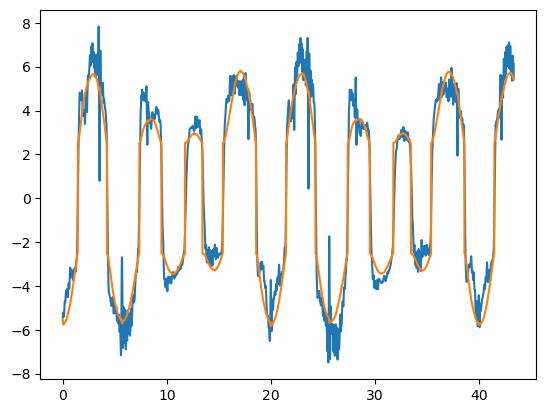

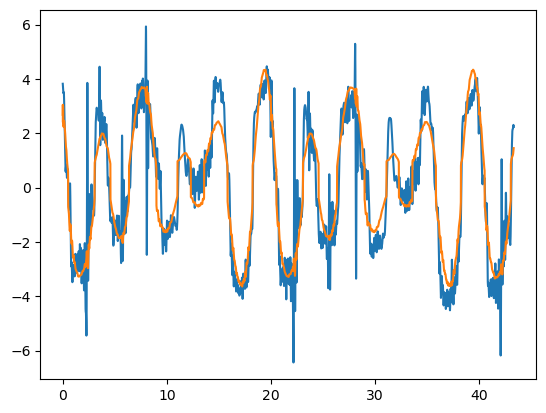

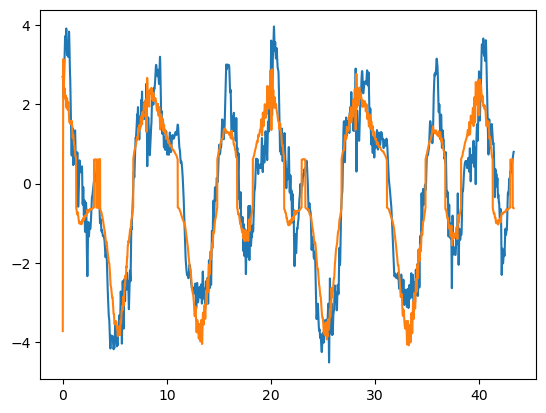

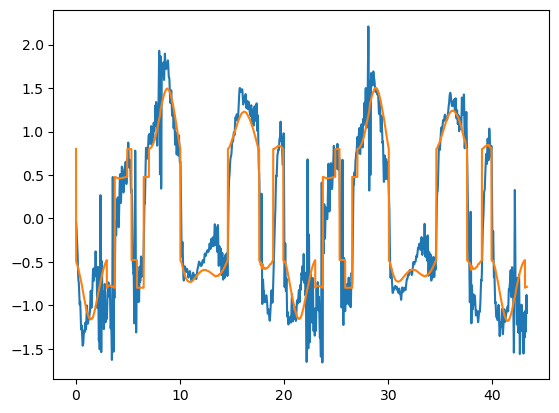

In [215]:
import matplotlib.pyplot as plt
tau_residual = tau_residual.reshape(-1, rbt.dof)
tau_residual_prediction = tau_residual_prediction.reshape(-1,rbt.dof)
for i in range(rbt.dof):

    plt.plot(t, tau_residual[:,i])
    plt.plot(t, tau_residual_prediction[:,i])
    plt.show()

(10829, 4)
(10829, 4)


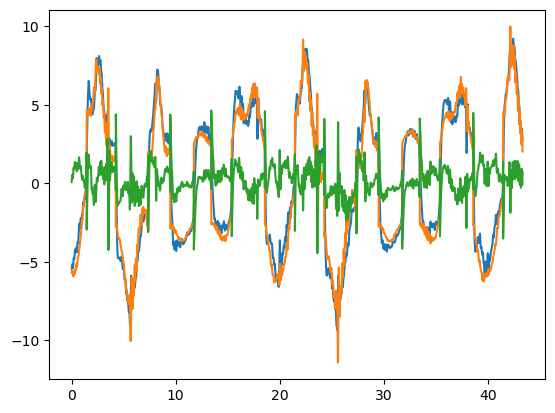

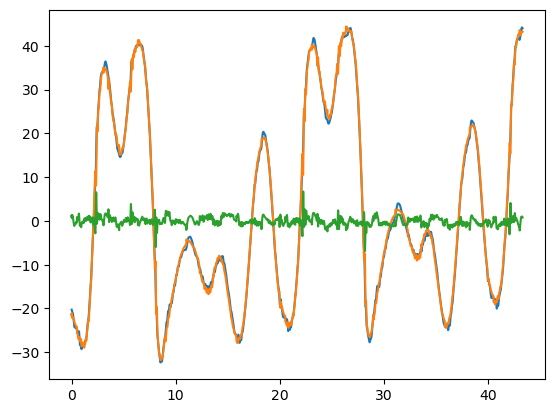

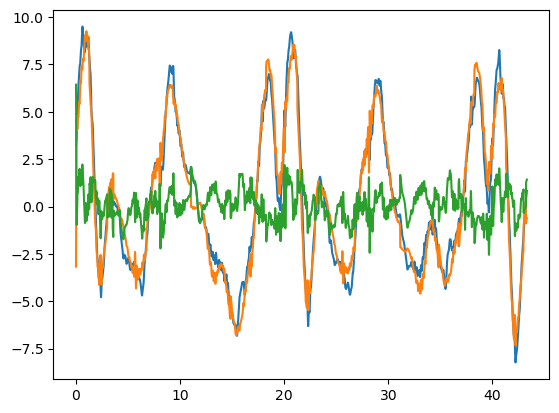

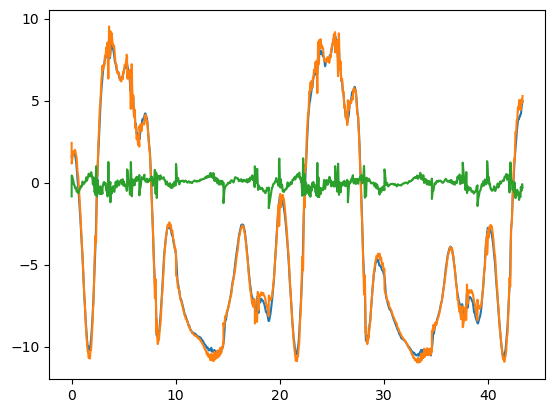

[0.9970714742879375,
 0.9779279424028018,
 0.8083510689654703,
 0.3554583378878738]

In [216]:
tau_vec = tau_vec.reshape(-1, rbt.dof)
tau_rbd = tau_rbd.reshape(-1, rbt.dof)
tau_residual_prediction = tau_residual_prediction.reshape(-1,rbt.dof)

tau_reconstructed = tau_rbd + tau_residual_prediction
tau_residual_after_reconstruction = tau_vec - tau_reconstructed

print(tau_reconstructed.shape)
print(tau_residual_after_reconstruction.shape)
rmse_vals = []

for i in range(rbt.dof):
    rmse_vals.append(rmse(tau_reconstructed[:,i], tau_vec[:,i]))
    plt.plot(t, tau_vec[:,i])
    plt.plot(t, tau_reconstructed[:,i])
    plt.plot(t, tau_residual_after_reconstruction[:,i])
    plt.show()
    
rmse_vals

In [154]:
print(f"Dataset used: {dataset}\n")

print(f"Full basis library used in sparse functional regression:\n")

print(basis_in)
print("--------\n")

for i in range(len(activateds)):
    print(f" ###### Joint {i} activated basis: #####")
    print(activateds[i])
    print(f" ## lambda value: ")
    print(lam_vals[i])
    print(f" ## Associated weights for the basis: ##")
    print(w_vects[i])
    print(f" ## RMSE between true and reconstructed torque (reconstructed = RBD + sparse functional regression terms): ##")
    print(rmse_vals[i])
    print(f" ## original RMSE between true and RBD torque: ##")
    print(np.sqrt(np.mean(np.square(tau_residual.reshape(-1,rbt.dof)[:,i]))))
    print()

Dataset used: recdata/rbtlog_16.dat

Full basis library used in sparse functional regression:

[cos(q_symbol), cos(dq_symbol), cos(ddq_symbol), q_symbol, dq_symbol, ddq_symbol, q_symbol**2, dq_symbol*q_symbol, ddq_symbol*q_symbol, dq_symbol**2, ddq_symbol*dq_symbol, ddq_symbol**2, sign(q_symbol), sign(dq_symbol), sign(ddq_symbol)]
--------

 ###### Joint 0 activated basis: #####
[dq_symbol, sign(dq_symbol)]
 ## lambda value: 
0.04
 ## Associated weights for the basis: ##
[0.0, 2.072433603980895, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.2574849344701313, 0.0]
 ## RMSE between true and reconstructed torque (reconstructed = RBD + sparse functional regression terms): ##
0.7241678012875675
 ## original RMSE between true and RBD torque: ##
3.692453305290489

 ###### Joint 1 activated basis: #####
[dq_symbol, q_symbol**2, ddq_symbol*q_symbol, sign(dq_symbol)]
 ## lambda value: 
0.06999999999999999
 ## Associated weights for the basis: ##
[2.5115645434964025, 0.0, 1.032486139778464, 0.0, 0.66

In [123]:
print(np.max(dq.reshape(-1,rbt.dof)[:,0]))
print(np.min(dq.reshape(-1,rbt.dof)[:,0]))

print(np.min

SyntaxError: unexpected EOF while parsing (3853665675.py, line 4)

## Sanity Check



In [1]:
# plot the discovered basis between the min and max of the data

j = q[:,0].copy()
min_q, max_q = np.min(q)

NameError: name 'q' is not defined

# SymINDy (Symbolic regression and SINDy algorithms)

pysindy: 1.6.3
sklearn: 1.0.2

utilizes the symindy module that i imported in the same directory as this notebook

In [38]:
from symindy.sym_sparse_regressor import SymSparseRegressor
import numpy as np


In [39]:
np.random.seed(0)

In [40]:
model = SymSparseRegressor(
    dims=3,
    ngen=5,
    ntrees=5,
    n_individuals=100,
    max_depth=2,
    verbose=True,
    regressor_kwargs={
        "alpha": 1e-2,
        "fit_intercept": True,
        "max_iter": 100000,
        "tol": 1e-2,
    },
    library_name = 'generalized',
    tr_te_ratio=None, #score on all data
    coef_tol = 1e-10, #threshold for determining active regression coefficients
)

INFO SymSparseRegressor__init__


In [66]:
trials_tau_residual_hat[-1].reshape(-1,rbt.dof)[:,0]

tau_residual=tau_residual.reshape(-1,rbt.dof)
q_0 = q[:,0]
dq_0 = dq[:,0]
ddq_0 = ddq[:,0]
# tau_residual_0 = tau_residual[:,0]

tau_residual_0 = tau_residual[:,0] - trials_tau_residual_hat[-1].reshape(-1,rbt.dof)[:,0] #try to use symbolic regression to model the residual 


Q_0 = np.column_stack([q_0, dq_0, ddq_0])
print(q_0.shape)
print(Q_0.shape)
print(tau_residual_0.shape)


from sklearn.preprocessing import StandardScaler

input_scaler = StandardScaler()
output_scaler = StandardScaler()

print("Q_0:", np.max(Q_0), np.min(Q_0))
print("tau_residual_0:", np.max(tau_residual_0), np.min(tau_residual_0))

Q_0_scaled = input_scaler.fit_transform(Q_0) #typically we would fit transform on the training batch but here jsut use all
tau_residual_0_scaled = output_scaler.fit_transform(tau_residual_0)

print("Q_0_scaled:", np.max(Q_0_scaled), np.min(Q_0_scaled))
print("tau_residual_0_scaled:", np.max(tau_residual_0_scaled), np.min(tau_residual_0_scaled))

model.fit(Q_0_scaled, tau_residual_0_scaled)

tau_predict_0_scaled = model.predict(Q_0_scaled)
tau_predict_0 = output_scaler.inverse_transform(tau_predict_0_scaled.reshape(-1,1)).ravel()

# print("Q_0:", np.max(Q_0), np.min(Q_0))
print("tau_predict_0:", np.max(tau_predict_0), np.min(tau_predict_0))

(10829,)
(10829, 3)
(10829, 1)
Q_0: 1.942464565156996 -13.280549463030297
tau_residual_0: 3.8304348331615587 -4.310948283626057
Q_0_scaled: 2.1308045705223946 -15.011029174556155
tau_residual_0_scaled: 4.891795038161156 -5.789927293105754
INFO SymSparseRegressor fit
INFO SymSparseRegressor configure_DEAP
Fitness: [-0.2667472870306159]


/home/oliveoil/miniconda3/envs/id/lib/python3.8/site-packages/sklearn/utils/validation.py:593: FutureWarning: np.matrix usage is deprecated in 1.0 and will raise a TypeError in 1.2. Please convert to a numpy array with np.asarray. For more information see: https://numpy.org/doc/stable/reference/generated/numpy.matrix.html
  warnings.warn(
/home/oliveoil/miniconda3/envs/id/lib/python3.8/site-packages/sklearn/utils/validation.py:593: FutureWarning: np.matrix usage is deprecated in 1.0 and will raise a TypeError in 1.2. Please convert to a numpy array with np.asarray. For more information see: https://numpy.org/doc/stable/reference/generated/numpy.matrix.html
  warnings.warn(


Fitness: [-0.04233629576560223]
Fitness: [-0.3014293924487595]
Fitness: [-0.16163393542894872]
Fitness: [-0.06703876168147453]
Fitness: [-0.04233156734380834]
Fitness: [-0.04233156734380834]
Fitness: [-0.11877126426707774]
Fitness: [-0.16260506810736636]
Fitness: [-0.2626484624986104]
Fitness: [-0.06377102906243019]
Fitness: [-0.04233156734380834]
Fitness: [-0.04233156734380834]
Fitness: [-0.09303141956009955]
Fitness: [-0.06377098574860122]
Fitness: [-0.21558174884743123]
Fitness: [-0.06516106405290316]
Fitness: [-0.16500893357297114]
Fitness: [-0.11245818494676219]
Fitness: [-0.1925619816057303]
Fitness: [-0.0887007637993015]
Fitness: [-0.08970597047958431]
Fitness: [-0.18749989041863308]
Fitness: [-0.04233205843699779]
Fitness: [-0.11722379373596725]
Fitness: [-0.14226213380384453]
Fitness: [-0.26706980326569074]
Fitness: [-0.24558355441638535]
Fitness: [-0.08872843531054256]
Fitness: [-0.04233205843699779]
Fitness: [-0.09036098209069246]
Fitness: [-0.06703876168147453]
Fitness: [-0

In [67]:
print("R2:", model.score(Q_0_scaled, tau_residual_0_scaled))

INFO SymSparseRegressor score
INFO SymSparseRegressor predict
R2: 0.006947823650795826


In [68]:
tau_rbd=tau_rbd.reshape(-1,rbt.dof)
tau_vec = tau_vec.reshape(-1,rbt.dof)
tau_predict_0 = tau_predict_0.reshape(-1,1)
reconstructed_0 = np.array(tau_predict_0 + tau_rbd[:,0] + trials_tau_residual_hat[-1].reshape(-1,rbt.dof)[:,0]).reshape(-1,1)
true_0 = tau_vec[:,0].reshape(-1,1)

In [69]:
reconstructed_0.shape, true_0.shape

((10829, 1), (10829, 1))

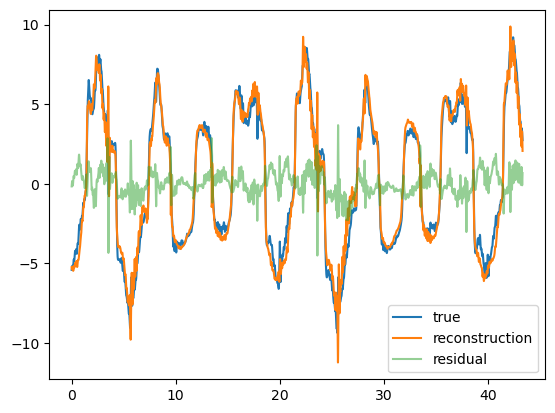

In [70]:
import matplotlib.pyplot as plt
plt.close()
plt.plot(t,true_0, label="true")
plt.plot(t,reconstructed_0, label="reconstruction")
plt.plot(t, true_0-reconstructed_0, alpha=0.5, label="residual")
plt.legend()
plt.show()

In [71]:
print("RMSE:", np.sqrt(np.mean(np.square(true_0-reconstructed_0))))

RMSE: 0.7595265184144988


## Notes on SymSparseRegressor attempt to recover model with Advanced WAM Model Basis:

Let the SymSparseRegressor utilize the 'advanced_wam_model' library (see the primitives in symindy/library.py).
Then, use GP algorithm to recover a good model.
Some parameters for sure need to be adjusted etc, but for now we can see that the selected regression terms are sign(x1), x1, which ironically is simply the Coulomb and Viscous friction model.

```
model = SymSparseRegressor(
    dims=3,
    ngen=5,
    ntrees=5,
    n_individuals=100,
    max_depth=3,
    verbose=True,
    regressor_kwargs={
        "alpha": 1e-2,
        "fit_intercept": True,
        "max_iter": 100000,
        "tol": 1e-2,
    },
    library_name = 'advanced_wam_model',
)
```
**OUTPUT FROM SPARSE GENETIC PROGRAMMING ALGORITHM**


Estimated symbolic features:
- f0: fourier_f5(fourier_f4(x0))
- f1: abs(fourier_f1(x1))
- f2: sign(x1)
- f3: x1
- f4: fourier_f5(fourier_f3(fourier_f5(x2)))

Selected sparse regression terms:
 2.555923 * f2
 2.520717 * f3
Intercept: 0.167099
Fitness: 0.912753
 

# TODO

## April 6:
- find the recovered terms and put them in the RBD model
- try just SINDy
- see if the SINDy recovered terms for j1 and j4 is similar, and see if j2 and j3 related? (we think j2,j3 related b/c of differential)
- use different datasets; filter to first 4 dof using the function in the github, and try on low velocity data
  it is okay that it takes a while to solve for the nonlinear components because this is offline

## April 9:
- consider modeling the external force, where torque = J.transpose @ force, where J is the geometric Jacobian (use DH mapping, del x/del joint 1, etc). when the robot is in free motion, the force is 0, but the predicted model fails to predict 0 ==> modeling error

## April 12:
Low pass filter causes a bit of cutoff:
tau_raw full joint4: -5.550959510693717 6.3373442742733985
tau filtered full joint4: -3.2948387500954346 2.1374862769383514
tau_raw sliced joint4: -3.790074372662456 2.441662560076463
tau filtered sliced joint4: -3.2948387500954346 1.9627279416335874
